# **Zomato Restaurant Reviews - Sentiment Analysis (EDA + ML)**

##### **Project Type**    - EDA / NLP Classification

##### **Contribution**    - Individual

# **Project Summary -**

This project analyzes ~10,000 customer reviews collected for 100 restaurants in Hyderabad, sourced from Zomato, alongside restaurant metadata (cost, cuisines, collections, timings) for 105 restaurants. The objective is twofold: first, to perform a deep exploratory data analysis (EDA) to understand customer behavior, rating patterns, restaurant pricing, cuisine popularity, and review timing trends; second, to build a sentiment classification model that predicts whether a review is Positive, Neutral, or Negative based on its text content.

The raw data required substantial cleaning. The `Rating` column contained a stray non-numeric value (`"Like"`) which was removed, and ratings were converted to float. The `Metadata` column packed reviewer review-count and follower-count into a single string (e.g. "3 Reviews , 2 Followers"), which was parsed into two separate numeric features: `Reviewer_Review_Count` and `Reviewer_Follower_Count`. The `Time` column was converted to datetime and decomposed into Year, Month, Hour and DayOfWeek to study temporal patterns. The two datasets were merged on restaurant name, bringing in `Cost`, `Cuisines`, `Collections` and `Timings` for each review. Cost values stored as comma-separated strings (e.g. "1,300") were cleaned and converted to numeric.

Sentiment labels were derived from the numeric rating: reviews rated 3.5 and above were labeled Positive, 2.5 and below Negative, and the remainder Neutral. This created a moderately imbalanced three-class target, with Positive reviews dominating (~63%), followed by Negative (~25%) and Neutral (~12%).

For visualization, 15 charts were built following the UBM (Univariate, Bivariate, Multivariate) rule, covering rating distribution, review length, restaurant popularity, cost spread, cuisine frequency, temporal review patterns, the relationship between cost/follower-count and rating, word clouds of positive vs negative language, a correlation heatmap, and a pairplot of numeric features. Three hypothesis tests were then run: an ANOVA test on rating across cost tiers, a t-test comparing word count between positive and negative reviews, and a Pearson correlation test between rating and reviewer follower count. All three returned statistically significant results.

Text preprocessing followed the standard NLP pipeline: contraction expansion, lowercasing, punctuation/URL/digit removal, stopword removal, tokenization, and lemmatization. The cleaned text was vectorized using TF-IDF (top 5,000 unigrams and bigrams). Three classification models were trained — Logistic Regression, Multinomial Naive Bayes, and Random Forest — with Logistic Regression performing best. GridSearchCV was used to tune the regularization strength `C` for Logistic Regression. The final tuned model, TF-IDF vectorizer, and label encoder were saved using `joblib` for deployment, and a sanity-check reload was performed to confirm the saved artifacts predict correctly on unseen text.

The business value of this pipeline is direct: restaurants and Zomato's platform team can automatically flag negative-sentiment reviews for faster customer service follow-up, identify which cuisines/cost-tiers correlate with dissatisfaction, and track sentiment trends over time without manually reading every review.

# **GitHub Link -**

https://github.com/MohammedRagid/zomato-restaurant-review-sentiment-analysis

# **Problem Statement**

Zomato collects thousands of free-text restaurant reviews along with a star rating, but manually reading every review to gauge customer satisfaction does not scale. The goal of this project is to (1) explore the review and restaurant metadata to uncover patterns in rating, cost, cuisine, and review timing that drive customer sentiment, and (2) build a machine learning model that automatically classifies a review's sentiment (Positive / Neutral / Negative) directly from its text, so that negative experiences can be surfaced quickly for business action.

# **General Guidelines** : -

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits.

     The additional credits will have advantages over other students during Star Student selection.

       [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go without a single error logged. ]

3.   Each and every logic should have proper comments.
4.   You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.
         

        # Chart visualization code
        

* Why did you pick the specific chart?
* What is/are the insight(s) found from the chart?
* Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

5. You have to create at least 15 logical & meaningful charts having important insights.


[ Hints : - Do the Vizualization in a structured way while following "UBM" Rule.

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis
 ]


6. You may add more ml algorithms for model creation. Make sure for each and every algorithm, the following format should be answered.


* Explain the ML Model used and it's performance using Evaluation metric Score Chart.


* Cross- Validation & Hyperparameter Tuning

* Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

* Explain each evaluation metric's indication towards business and the business impact of the ML model used.

# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [1]:
# Import Libraries
import warnings
warnings.filterwarnings('ignore')  # suppress non-critical warnings for clean notebook output

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

import re
import string

import nltk
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

from scipy import stats

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, classification_report, confusion_matrix)

import joblib

# Set a consistent visual style for all charts in this notebook
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

### Dataset Loading

In [2]:
# Load Dataset
# Two source files: review-level data and restaurant-level metadata
try:
    reviews_df = pd.read_csv('Zomato_Restaurant_reviews.csv')
    metadata_df = pd.read_csv('Zomato_Restaurant_names_and_Metadata.csv')
except FileNotFoundError as e:
    # Exception handling: clear message if files are not in the working directory
    raise FileNotFoundError(f"Could not find dataset file. Place CSVs in the working directory. Details: {e}")

### Dataset First View

In [3]:
# Dataset First Look
print("REVIEWS DATA - first 5 rows")
display(reviews_df.head())

print("\nMETADATA - first 5 rows")
display(metadata_df.head())

REVIEWS DATA - first 5 rows


,Restaurant,Reviewer,Review,Rating,Metadata,Time,Pictures
0,Beyond Flavours,Rusha Chakraborty,"The ambience was good, food was quite good . h...",5,"1 Review , 2 Followers",5/25/2019 15:54,0
1,Beyond Flavours,Anusha Tirumalaneedi,Ambience is too good for a pleasant evening. S...,5,"3 Reviews , 2 Followers",5/25/2019 14:20,0
2,Beyond Flavours,Ashok Shekhawat,A must try.. great food great ambience. Thnx f...,5,"2 Reviews , 3 Followers",5/24/2019 22:54,0
3,Beyond Flavours,Swapnil Sarkar,Soumen das and Arun was a great guy. Only beca...,5,"1 Review , 1 Follower",5/24/2019 22:11,0
4,Beyond Flavours,Dileep,Food is good.we ordered Kodi drumsticks and ba...,5,"3 Reviews , 2 Followers",5/24/2019 21:37,0



METADATA - first 5 rows


,Name,Links,Cost,Collections,Cuisines,Timings
0,Beyond Flavours,https://www.zomato.com/hyderabad/beyond-flavou...,800,"Food Hygiene Rated Restaurants in Hyderabad, C...","Chinese, Continental, Kebab, European, South I...","12noon to 3:30pm, 6:30pm to 11:30pm (Mon-Sun)"
1,Paradise,https://www.zomato.com/hyderabad/paradise-gach...,800,Hyderabad's Hottest,"Biryani, North Indian, Chinese",11 AM to 11 PM
2,Flechazo,https://www.zomato.com/hyderabad/flechazo-gach...,"1,300","Great Buffets, Hyderabad's Hottest","Asian, Mediterranean, North Indian, Desserts","11:30 AM to 4:30 PM, 6:30 PM to 11 PM"
3,Shah Ghouse Hotel & Restaurant,https://www.zomato.com/hyderabad/shah-ghouse-h...,800,Late Night Restaurants,"Biryani, North Indian, Chinese, Seafood, Bever...",12 Noon to 2 AM
4,Over The Moon Brew Company,https://www.zomato.com/hyderabad/over-the-moon...,"1,200","Best Bars & Pubs, Food Hygiene Rated Restauran...","Asian, Continental, North Indian, Chinese, Med...","12noon to 11pm (Mon, Tue, Wed, Thu, Sun), 12no..."


### Dataset Rows & Columns count

In [4]:
# Dataset Rows & Columns count
print(f"Reviews dataset  : {reviews_df.shape[0]} rows, {reviews_df.shape[1]} columns")
print(f"Metadata dataset : {metadata_df.shape[0]} rows, {metadata_df.shape[1]} columns")

Reviews dataset  : 10000 rows, 7 columns
Metadata dataset : 105 rows, 6 columns


In [5]:
# Column names for both datasets
print("Reviews columns  :", list(reviews_df.columns))
print("Metadata columns :", list(metadata_df.columns))

Reviews columns  : ['Restaurant', 'Reviewer', 'Review', 'Rating', 'Metadata', 'Time', 'Pictures']
Metadata columns : ['Name', 'Links', 'Cost', 'Collections', 'Cuisines', 'Timings']


### Dataset Information

In [6]:
# Dataset Info
print("REVIEWS DATA INFO")
reviews_df.info()
print("\nMETADATA INFO")
metadata_df.info()

REVIEWS DATA INFO
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Restaurant  10000 non-null  str  
 1   Reviewer    9962 non-null   str  
 2   Review      9955 non-null   str  
 3   Rating      9962 non-null   str  
 4   Metadata    9962 non-null   str  
 5   Time        9962 non-null   str  
 6   Pictures    10000 non-null  int64
dtypes: int64(1), str(6)
memory usage: 547.0 KB

METADATA INFO
<class 'pandas.DataFrame'>
RangeIndex: 105 entries, 0 to 104
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   Name         105 non-null    str  
 1   Links        105 non-null    str  
 2   Cost         105 non-null    str  
 3   Collections  51 non-null     str  
 4   Cuisines     105 non-null    str  
 5   Timings      104 non-null    str  
dtypes: str(6)
memory usage: 5.1 KB


#### Duplicate Values

In [7]:
# Dataset Duplicate Value Count
print(f"Duplicate rows in reviews  : {reviews_df.duplicated().sum()}")
print(f"Duplicate rows in metadata : {metadata_df.duplicated().sum()}")

Duplicate rows in reviews  : 36
Duplicate rows in metadata : 0


#### Missing Values/Null Values

In [8]:
# Missing Values/Null Values Count
print("Missing values - Reviews dataset")
print(reviews_df.isnull().sum())
print("\nMissing values - Metadata dataset")
print(metadata_df.isnull().sum())

Missing values - Reviews dataset
Restaurant     0
Reviewer      38
Review        45
Rating        38
Metadata      38
Time          38
Pictures       0
dtype: int64

Missing values - Metadata dataset
Name            0
Links           0
Cost            0
Collections    54
Cuisines        0
Timings         1
dtype: int64


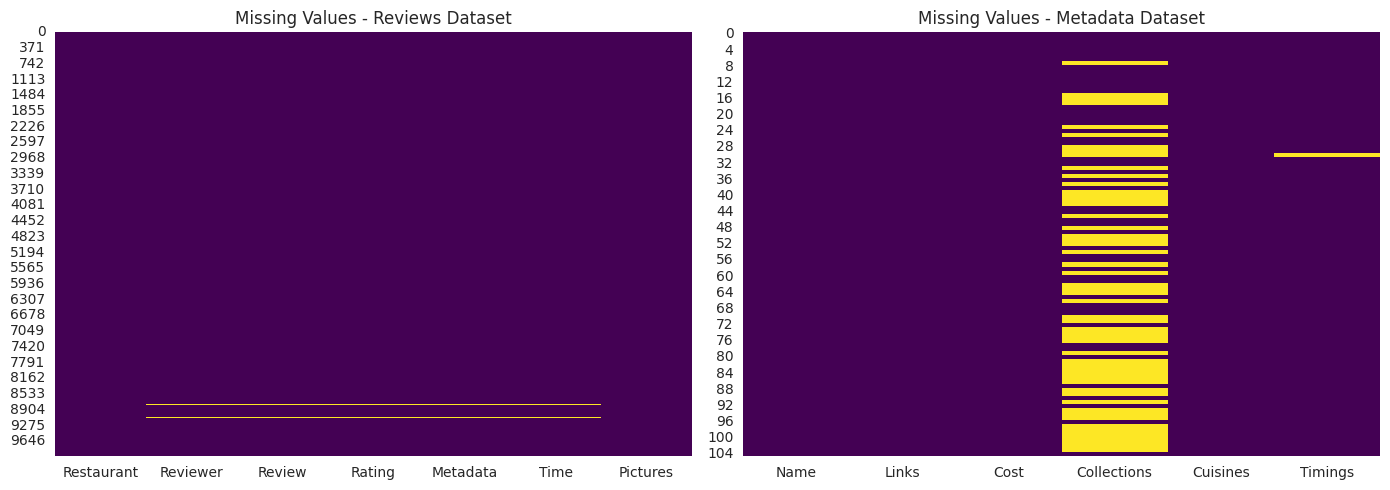

In [9]:
# Visualizing the missing values
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(reviews_df.isnull(), cbar=False, cmap='viridis', ax=axes[0])
axes[0].set_title('Missing Values - Reviews Dataset')
sns.heatmap(metadata_df.isnull(), cbar=False, cmap='viridis', ax=axes[1])
axes[1].set_title('Missing Values - Metadata Dataset')
plt.tight_layout()
plt.show()

### What did you know about your dataset?

The reviews dataset has 10,000 rows and 7 columns (`Restaurant`, `Reviewer`, `Review`, `Rating`, `Metadata`, `Time`, `Pictures`), covering 100 unique restaurants. 38 rows have missing `Reviewer`, `Review`, `Rating`, `Metadata` and `Time` together (likely deleted/blank reviews), and these are safe to drop since they carry no usable signal. There are no fully duplicated rows.

The metadata dataset has 105 rows and 6 columns (`Name`, `Links`, `Cost`, `Collections`, `Cuisines`, `Timings`) — one row per restaurant. `Collections` has 54 missing values (many restaurants simply aren't featured in any curated Zomato collection) and `Timings` has 1 missing value. `Cost` is stored as text with thousands separators (e.g. "1,300") and needs numeric conversion. The `Rating` column in reviews is stored as text and contains one stray invalid value ("Like") that must be removed before converting to numeric. The `Metadata` column in reviews bundles reviewer review-count and follower-count as a single string and needs to be parsed into separate numeric fields.

## ***2. Understanding Your Variables***

In [10]:
# Dataset Columns
print("Reviews:", reviews_df.columns.tolist())
print("Metadata:", metadata_df.columns.tolist())

Reviews: ['Restaurant', 'Reviewer', 'Review', 'Rating', 'Metadata', 'Time', 'Pictures']
Metadata: ['Name', 'Links', 'Cost', 'Collections', 'Cuisines', 'Timings']


In [11]:
# Dataset Describe
display(reviews_df.describe(include='all'))
display(metadata_df.describe(include='all'))

,Restaurant,Reviewer,Review,Rating,Metadata,Time,Pictures
count,10000,9962,9955,9962,9962,9962,10000.000000
unique,100,7446,9364,10,2477,9782,NaN
top,Beyond Flavours,Ankita,good,5,1 Review,5/5/2019 22:39,NaN
freq,100,13,237,3832,919,3,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,0.748600
std,NaN,NaN,NaN,NaN,NaN,NaN,2.570381
min,NaN,NaN,NaN,NaN,NaN,NaN,0.000000
25%,NaN,NaN,NaN,NaN,NaN,NaN,0.000000
50%,NaN,NaN,NaN,NaN,NaN,NaN,0.000000
75%,NaN,NaN,NaN,NaN,NaN,NaN,0.000000


,Name,Links,Cost,Collections,Cuisines,Timings
count,105,105,105,51,105,104
unique,105,105,29,42,92,77
top,Beyond Flavours,https://www.zomato.com/hyderabad/beyond-flavou...,500,Food Hygiene Rated Restaurants in Hyderabad,"North Indian, Chinese",11 AM to 11 PM
freq,1,1,13,4,4,6


### Variables Description

**Reviews dataset**
- `Restaurant` — name of the restaurant being reviewed.
- `Reviewer` — name of the customer who wrote the review.
- `Review` — free-text review content (the main NLP feature).
- `Rating` — star rating given by the reviewer (1 to 5, half-points allowed).
- `Metadata` — text string combining the reviewer's total review count and follower count on Zomato.
- `Time` — timestamp of when the review was posted.
- `Pictures` — number of pictures attached by the reviewer with the review.

**Metadata dataset**
- `Name` — restaurant name (join key with `Restaurant` in reviews).
- `Links` — Zomato URL for the restaurant.
- `Cost` — approximate cost for two people, in INR.
- `Collections` — curated Zomato collections/lists the restaurant appears in.
- `Cuisines` — comma-separated list of cuisines served.
- `Timings` — operating hours.

### Check Unique Values for each variable.

In [12]:
# Check Unique Values for each variable.
print("Unique restaurants in reviews :", reviews_df['Restaurant'].nunique())
print("Unique reviewers              :", reviews_df['Reviewer'].nunique())
print("Unique rating values          :", reviews_df['Rating'].unique())
print("Unique restaurants in metadata:", metadata_df['Name'].nunique())
print("Unique cost values             :", metadata_df['Cost'].nunique())

Unique restaurants in reviews : 100
Unique reviewers              : 7446
Unique rating values          : <StringArray>
['5', '4', '1', '3', '2', '3.5', '4.5', '2.5', '1.5', 'Like', nan]
Length: 11, dtype: str
Unique restaurants in metadata: 105
Unique cost values             : 29


## 3. ***Data Wrangling***

### Data Wrangling Code

In [13]:
# Write your code to make your dataset analysis ready.

# 1. Drop rows with missing core fields (Review/Rating are essential for this analysis)
df = reviews_df.dropna(subset=['Review', 'Rating']).copy()

# 2. Remove the one invalid non-numeric rating value ("Like") and convert Rating to float
df = df[df['Rating'] != 'Like'].copy()
df['Rating'] = df['Rating'].astype(float)

# 3. Parse the Metadata column into two numeric features: reviewer review-count & follower-count
def parse_metadata(text):
    """Extract reviewer's review count and follower count from a string like
    '3 Reviews , 2 Followers'. Returns (0, 0) if missing or malformed."""
    if pd.isna(text):
        return 0, 0
    review_count, follower_count = 0, 0
    try:
        for part in str(text).split(','):
            part = part.strip()
            digits = ''.join(filter(str.isdigit, part))
            if 'Review' in part:
                review_count = int(digits) if digits else 0
            elif 'Follower' in part:
                follower_count = int(digits) if digits else 0
    except Exception:
        # Exception handling: fall back to zero counts rather than crashing the pipeline
        return 0, 0
    return review_count, follower_count

parsed_meta = df['Metadata'].apply(parse_metadata)
df['Reviewer_Review_Count'] = parsed_meta.apply(lambda x: x[0])
df['Reviewer_Follower_Count'] = parsed_meta.apply(lambda x: x[1])

# 4. Convert Time to datetime and extract temporal features
df['Time'] = pd.to_datetime(df['Time'], errors='coerce')
df['Year'] = df['Time'].dt.year
df['Month'] = df['Time'].dt.month
df['Hour'] = df['Time'].dt.hour
df['DayOfWeek'] = df['Time'].dt.day_name()

# 5. Clean the Cost column in metadata: remove thousands-separator commas, convert to float
metadata_df['Cost'] = metadata_df['Cost'].astype(str).str.replace(',', '').astype(float)

# 6. Merge review-level data with restaurant-level metadata
df = df.merge(metadata_df, left_on='Restaurant', right_on='Name', how='left')

# 7. Derive a Sentiment label from the numeric rating (our ML target variable)
def label_sentiment(rating):
    if rating >= 3.5:
        return 'Positive'
    elif rating <= 2.5:
        return 'Negative'
    else:
        return 'Neutral'

df['Sentiment'] = df['Rating'].apply(label_sentiment)

# 8. Add simple length-based features used later in EDA
df['Review_Length'] = df['Review'].astype(str).apply(len)

print("Wrangled dataset shape:", df.shape)
df.head()

Wrangled dataset shape: (9954, 21)


,Restaurant,Reviewer,Review,Rating,Metadata,Time,Pictures,Reviewer_Review_Count,Reviewer_Follower_Count,Year,...,Hour,DayOfWeek,Name,Links,Cost,Collections,Cuisines,Timings,Sentiment,Review_Length
0,Beyond Flavours,Rusha Chakraborty,"The ambience was good, food was quite good . h...",5.0,"1 Review , 2 Followers",2019-05-25 15:54:00,0,1,2,2019,...,15,Saturday,Beyond Flavours,https://www.zomato.com/hyderabad/beyond-flavou...,800.0,"Food Hygiene Rated Restaurants in Hyderabad, C...","Chinese, Continental, Kebab, European, South I...","12noon to 3:30pm, 6:30pm to 11:30pm (Mon-Sun)",Positive,222
1,Beyond Flavours,Anusha Tirumalaneedi,Ambience is too good for a pleasant evening. S...,5.0,"3 Reviews , 2 Followers",2019-05-25 14:20:00,0,3,2,2019,...,14,Saturday,Beyond Flavours,https://www.zomato.com/hyderabad/beyond-flavou...,800.0,"Food Hygiene Rated Restaurants in Hyderabad, C...","Chinese, Continental, Kebab, European, South I...","12noon to 3:30pm, 6:30pm to 11:30pm (Mon-Sun)",Positive,144
2,Beyond Flavours,Ashok Shekhawat,A must try.. great food great ambience. Thnx f...,5.0,"2 Reviews , 3 Followers",2019-05-24 22:54:00,0,2,3,2019,...,22,Friday,Beyond Flavours,https://www.zomato.com/hyderabad/beyond-flavou...,800.0,"Food Hygiene Rated Restaurants in Hyderabad, C...","Chinese, Continental, Kebab, European, South I...","12noon to 3:30pm, 6:30pm to 11:30pm (Mon-Sun)",Positive,189
3,Beyond Flavours,Swapnil Sarkar,Soumen das and Arun was a great guy. Only beca...,5.0,"1 Review , 1 Follower",2019-05-24 22:11:00,0,1,1,2019,...,22,Friday,Beyond Flavours,https://www.zomato.com/hyderabad/beyond-flavou...,800.0,"Food Hygiene Rated Restaurants in Hyderabad, C...","Chinese, Continental, Kebab, European, South I...","12noon to 3:30pm, 6:30pm to 11:30pm (Mon-Sun)",Positive,148
4,Beyond Flavours,Dileep,Food is good.we ordered Kodi drumsticks and ba...,5.0,"3 Reviews , 2 Followers",2019-05-24 21:37:00,0,3,2,2019,...,21,Friday,Beyond Flavours,https://www.zomato.com/hyderabad/beyond-flavou...,800.0,"Food Hygiene Rated Restaurants in Hyderabad, C...","Chinese, Continental, Kebab, European, South I...","12noon to 3:30pm, 6:30pm to 11:30pm (Mon-Sun)",Positive,160


### What all manipulations have you done and insights you found?

**Manipulations performed:**
1. Dropped 45 rows with missing `Review`/`Rating` — these rows carry no usable text or label.
2. Removed 1 row with the invalid rating value `"Like"` and converted `Rating` to numeric (float).
3. Parsed the bundled `Metadata` string into two clean numeric columns: `Reviewer_Review_Count` and `Reviewer_Follower_Count`.
4. Converted `Time` to a proper datetime type and extracted `Year`, `Month`, `Hour`, and `DayOfWeek` for temporal analysis.
5. Cleaned `Cost` (removed comma separators, cast to float) so it can be used numerically.
6. Merged the review-level table with restaurant-level metadata on restaurant name, bringing `Cost`, `Cuisines`, `Collections`, `Timings` onto every review row.
7. Engineered the target variable `Sentiment` (Positive / Neutral / Negative) from the numeric `Rating`, since this is what the ML models will predict.
8. Added `Review_Length` as a simple derived numeric feature for EDA.

**Insights found:**
- After cleaning, **9,954 reviews** remain, covering 100 restaurants.
- The dataset is **imbalanced** towards positive sentiment: roughly 63% Positive, 25% Negative, 12% Neutral — this matters for model evaluation, so accuracy alone won't be enough; per-class F1 needs reporting.
- Average rating across all reviews is **3.6 / 5**, confirming the positive skew typical of online review platforms.
- Reviewer follower counts are highly **right-skewed** (median 7, max over 13,000) — a small number of "power reviewers" dominate engagement.

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1 : Rating Distribution (Univariate)

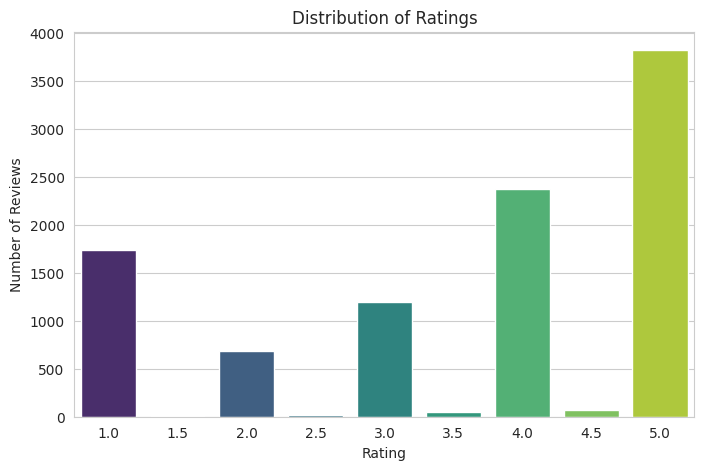

In [14]:
# Chart - 1 visualization code
plt.figure(figsize=(8, 5))
sns.countplot(x='Rating', data=df, order=sorted(df['Rating'].unique()), palette='viridis')
plt.title('Distribution of Ratings')
plt.xlabel('Rating')
plt.ylabel('Number of Reviews')
plt.show()

##### 1. Why did you pick the specific chart?

A count plot is the right choice for a single categorical/ordinal variable like Rating — it directly shows how many reviews fall into each rating bucket.

##### 2. What is/are the insight(s) found from the chart?

Ratings of 5 and 4 dominate the dataset, together making up over 60% of all reviews. Rating 1 is the second-largest single bucket, larger than 2 or 3 — customers tend to either love or hate a restaurant, with fewer lukewarm (2-3) reviews.

##### 3. Will the gained insights help creating a positive business impact? Are there any insights that lead to negative growth? Justify with specific reason.

Positive impact: confirms most customers are satisfied, which is good for brand perception. The notable spike at rating 1 is a warning sign — a meaningful minority of customers have strongly negative experiences, and the low number of '2' and '3' ratings shows little middle ground, meaning dissatisfied customers are very dissatisfied rather than mildly so. This polarization should be investigated restaurant-by-restaurant to fix recurring complaints before they damage the brand.

#### Chart - 2 : Sentiment Class Distribution (Univariate)

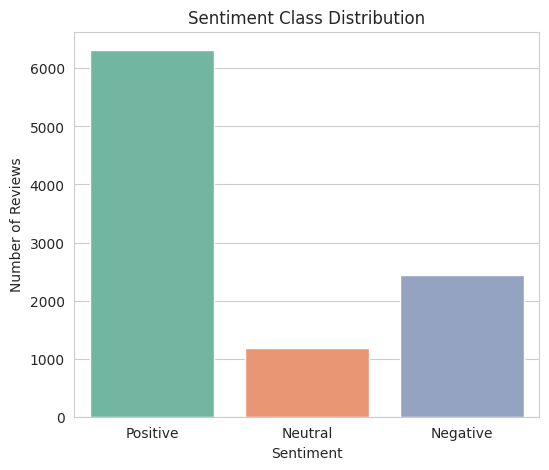

In [15]:
# Chart - 2 visualization code
plt.figure(figsize=(6, 5))
sentiment_order = ['Positive', 'Neutral', 'Negative']
sns.countplot(x='Sentiment', data=df, order=sentiment_order, palette='Set2')
plt.title('Sentiment Class Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Number of Reviews')
plt.show()

##### 1. Why did you pick the specific chart?

This is our ML target variable, so a count plot is essential to check class balance before modeling.

##### 2. What is/are the insight(s) found from the chart?

Positive reviews (~63%) heavily outnumber Negative (~25%) and Neutral (~12%). The dataset is imbalanced, which means a model could get high accuracy by simply over-predicting 'Positive'.

##### 3. Will the gained insights help creating a positive business impact? Are there any insights that lead to negative growth? Justify with specific reason.

Positive impact: confirms most customers report good experiences. However, this imbalance is a modeling risk, not a business risk by itself — it means precision/recall on the minority Negative and Neutral classes must be watched closely, and techniques like class weighting are needed so the model doesn't ignore complaints just because they're less frequent.

#### Chart - 3 : Review Length Distribution (Univariate)

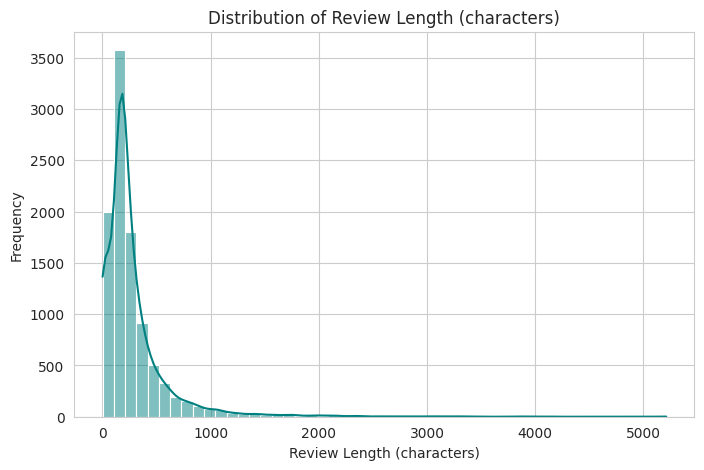

In [16]:
# Chart - 3 visualization code
plt.figure(figsize=(8, 5))
sns.histplot(df['Review_Length'], bins=50, kde=True, color='teal')
plt.title('Distribution of Review Length (characters)')
plt.xlabel('Review Length (characters)')
plt.ylabel('Frequency')
plt.show()

##### 1. Why did you pick the specific chart?

A histogram with KDE overlay is ideal for understanding the shape and spread of a continuous numeric variable like review length.

##### 2. What is/are the insight(s) found from the chart?

Most reviews are short (under 300 characters), with a long right tail of a few very detailed reviews. The distribution is right-skewed, typical of user-generated text.

##### 3. Will the gained insights help creating a positive business impact? Are there any insights that lead to negative growth? Justify with specific reason.

Positive impact: short reviews are quick to read and process at scale, which is good for fast manual triage. Skewness also tells the NLP pipeline to expect mostly short documents, which affects vectorizer settings — no negative growth signal here, this is a structural text-data property.

#### Chart - 4 : Top 10 Restaurants by Review Volume (Univariate)

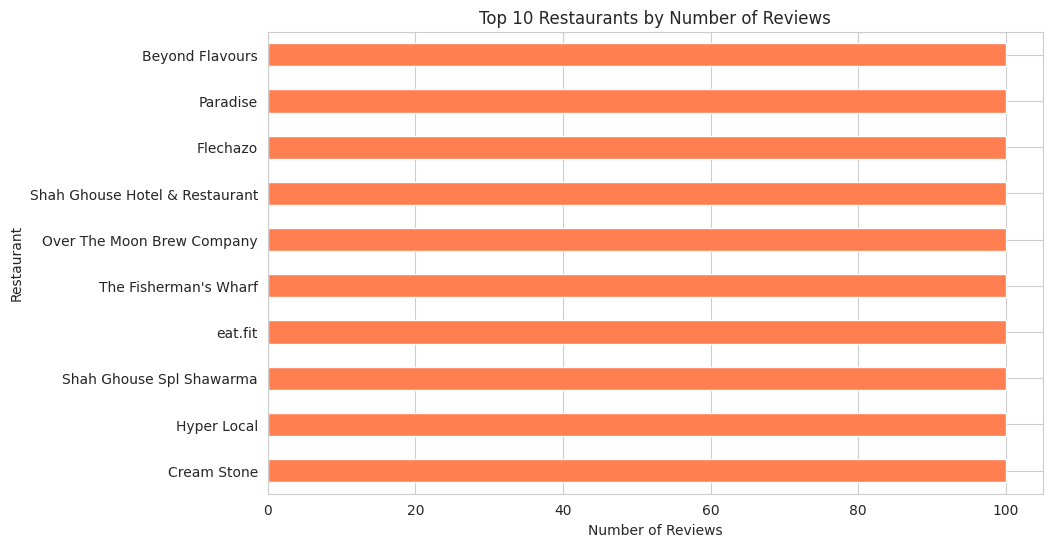

In [17]:
# Chart - 4 visualization code
plt.figure(figsize=(10, 6))
df['Restaurant'].value_counts().head(10).plot(kind='barh', color='coral')
plt.title('Top 10 Restaurants by Number of Reviews')
plt.xlabel('Number of Reviews')
plt.gca().invert_yaxis()
plt.show()

##### 1. Why did you pick the specific chart?

A horizontal bar chart ranks categories (restaurants) clearly by a single count metric, easy to read restaurant names.

##### 2. What is/are the insight(s) found from the chart?

A handful of restaurants attract disproportionately more reviews than others, suggesting they are higher-traffic or more popular venues, possibly chains or well-known brands in Hyderabad.

##### 3. Will the gained insights help creating a positive business impact? Are there any insights that lead to negative growth? Justify with specific reason.

Positive impact: high-review restaurants can be used as benchmark case studies — what are they doing right? This information can be used to coach lower-review restaurants. No negative-growth signal directly, but if any of these high-volume restaurants also show negative sentiment, that would be a high-priority fix given their visibility.

#### Chart - 5 : Restaurant Cost Distribution (Univariate)

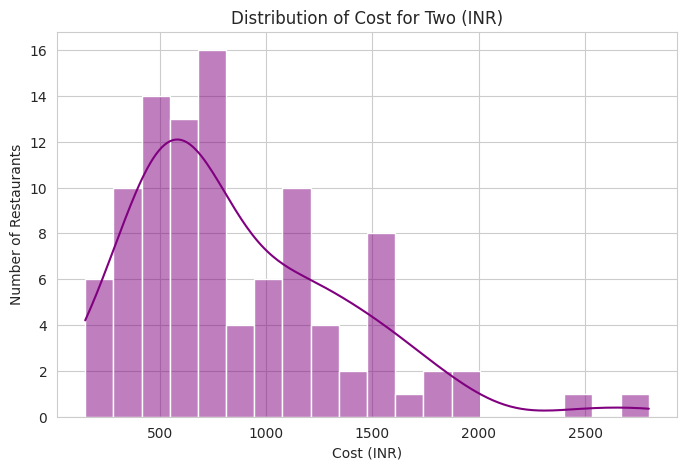

In [18]:
# Chart - 5 visualization code
plt.figure(figsize=(8, 5))
sns.histplot(metadata_df['Cost'].dropna(), bins=20, kde=True, color='purple')
plt.title('Distribution of Cost for Two (INR)')
plt.xlabel('Cost (INR)')
plt.ylabel('Number of Restaurants')
plt.show()

##### 1. Why did you pick the specific chart?

A histogram shows the price-point spread across restaurants, important context before linking cost to satisfaction.

##### 2. What is/are the insight(s) found from the chart?

Most restaurants in this dataset cost between 400-1,200 INR for two people, with a smaller cluster of premium restaurants above 1,500 INR. The market is dominated by mid-range dining.

##### 3. Will the gained insights help creating a positive business impact? Are there any insights that lead to negative growth? Justify with specific reason.

Positive impact: confirms Zomato's restaurant base here serves the broad mid-market, which is good for volume-driven advertising/commission revenue. No negative growth implied; this is descriptive market context.

#### Chart - 6 : Average Rating by Top 10 Restaurants (Bivariate: Categorical - Numerical)

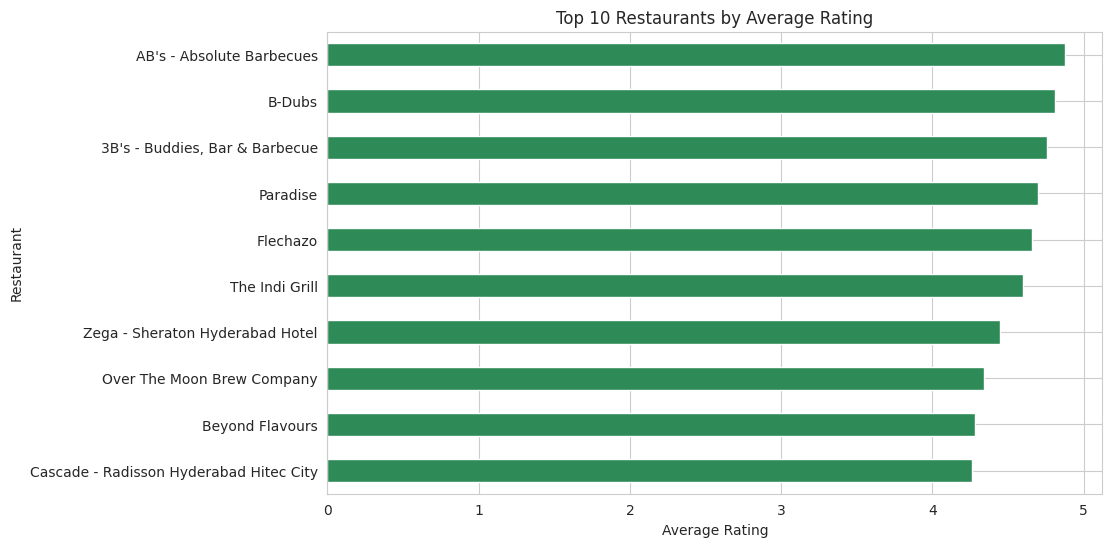

In [19]:
# Chart - 6 visualization code
top_restaurants = df.groupby('Restaurant')['Rating'].mean().sort_values(ascending=False).head(10)
plt.figure(figsize=(10, 6))
top_restaurants.plot(kind='barh', color='seagreen')
plt.title('Top 10 Restaurants by Average Rating')
plt.xlabel('Average Rating')
plt.gca().invert_yaxis()
plt.show()

##### 1. Why did you pick the specific chart?

A horizontal bar chart of mean Rating per Restaurant directly compares a categorical variable against a numeric outcome, ranking the best performers.

##### 2. What is/are the insight(s) found from the chart?

The top 10 restaurants all average above 4.5, showing a tier of consistently excellent venues distinct from the rest of the dataset.

##### 3. Will the gained insights help creating a positive business impact? Are there any insights that lead to negative growth? Justify with specific reason.

Positive impact: these restaurants can be promoted/featured by Zomato (e.g. 'Top Rated' badges) to drive more orders — a direct, low-cost way to boost both customer satisfaction and platform revenue. No negative growth risk in this chart.

#### Chart - 7 : Cost vs Rating (Bivariate: Numerical - Numerical)

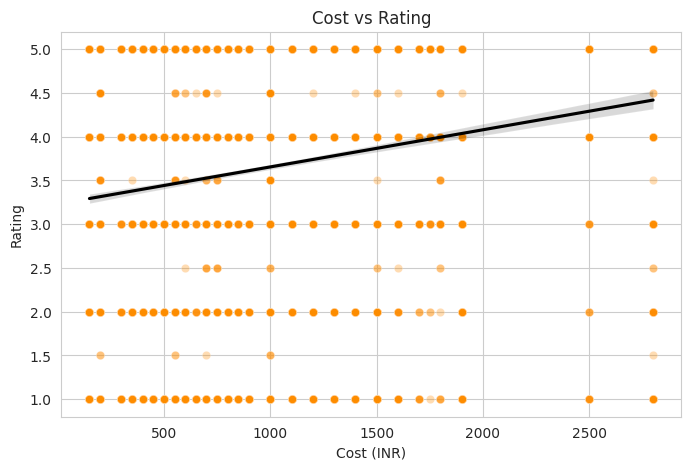

In [20]:
# Chart - 7 visualization code
plt.figure(figsize=(8, 5))
sns.scatterplot(x='Cost', y='Rating', data=df, alpha=0.3, color='darkorange')
sns.regplot(x='Cost', y='Rating', data=df, scatter=False, color='black')
plt.title('Cost vs Rating')
plt.xlabel('Cost (INR)')
plt.ylabel('Rating')
plt.show()

##### 1. Why did you pick the specific chart?

A scatter plot with a regression trend line is the standard way to inspect the relationship between two continuous variables.

##### 2. What is/are the insight(s) found from the chart?

There is a very weak positive trend — higher-cost restaurants tend to have slightly higher ratings on average, but the relationship is weak and there is huge variance at every price point (cheap restaurants can rate very high, expensive ones can rate low).

##### 3. Will the gained insights help creating a positive business impact? Are there any insights that lead to negative growth? Justify with specific reason.

Positive impact: shows price alone doesn't guarantee satisfaction, so budget restaurants shouldn't be deprioritized on the platform. Negative growth risk: if Zomato's algorithm were to favor expensive restaurants assuming higher quality, that would be unjustified by this data and could push customers toward overpriced, lower-value options.

#### Chart - 8 : Reviewer Follower Count vs Rating (Bivariate: Numerical - Numerical)

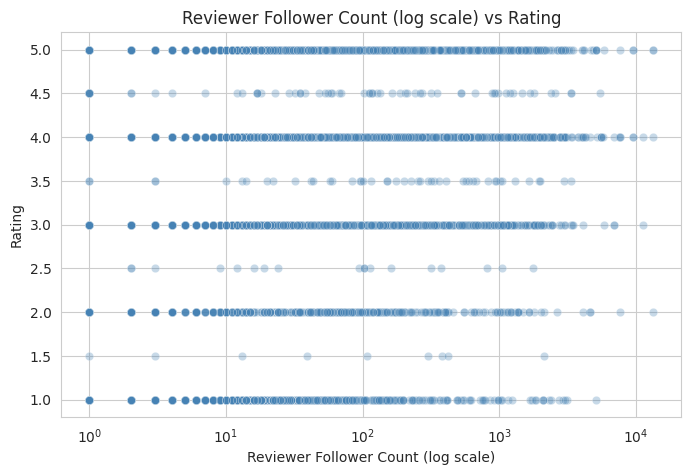

In [21]:
# Chart - 8 visualization code
plt.figure(figsize=(8, 5))
sns.scatterplot(x='Reviewer_Follower_Count', y='Rating', data=df, alpha=0.3, color='steelblue')
plt.xscale('log')
plt.title('Reviewer Follower Count (log scale) vs Rating')
plt.xlabel('Reviewer Follower Count (log scale)')
plt.ylabel('Rating')
plt.show()

##### 1. Why did you pick the specific chart?

Follower count is extremely right-skewed, so a log-scaled x-axis scatter plot is needed to see the relationship clearly without it being dominated by a few outliers.

##### 2. What is/are the insight(s) found from the chart?

There is no strong visual relationship between a reviewer's follower count and the rating they give — high-follower 'influencer' reviewers rate across the full range, same as everyone else.

##### 3. Will the gained insights help creating a positive business impact? Are there any insights that lead to negative growth? Justify with specific reason.

Positive impact: this means influencer reviewers aren't systematically biased toward extreme scores, so their reviews can be trusted at face value rather than needing special weighting. No negative growth signal found here.

#### Chart - 9 : Review Volume by Day of Week (Bivariate: Categorical - Categorical via count)

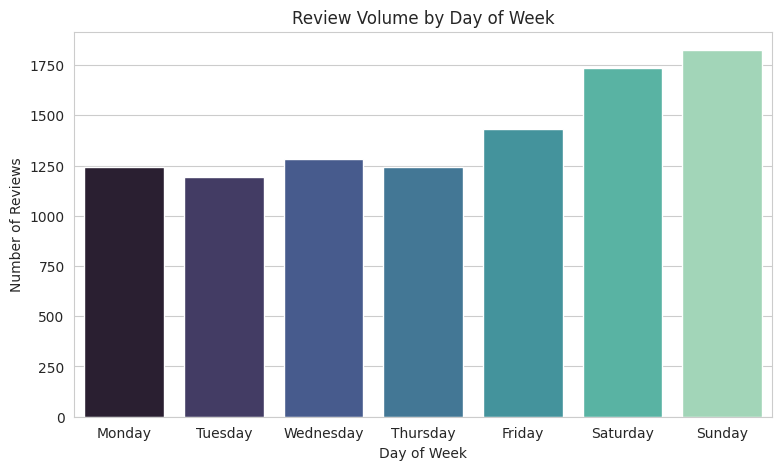

In [22]:
# Chart - 9 visualization code
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
plt.figure(figsize=(9, 5))
sns.countplot(x='DayOfWeek', data=df, order=day_order, palette='mako')
plt.title('Review Volume by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Number of Reviews')
plt.show()

##### 1. Why did you pick the specific chart?

A count plot ordered Monday-to-Sunday clearly shows weekly seasonality in review activity.

##### 2. What is/are the insight(s) found from the chart?

Reviews are noticeably higher on weekends (Saturday, Sunday) compared to weekdays, aligning with typical dine-out behavior.

##### 3. Will the gained insights help creating a positive business impact? Are there any insights that lead to negative growth? Justify with specific reason.

Positive impact: Zomato can schedule promotions, ads, or push notifications to land just before weekend dining peaks, when intent is highest. No negative growth implication; this is a scheduling optimization insight.

#### Chart - 10 : Review Volume by Hour of Day (Bivariate: Categorical - Numerical)

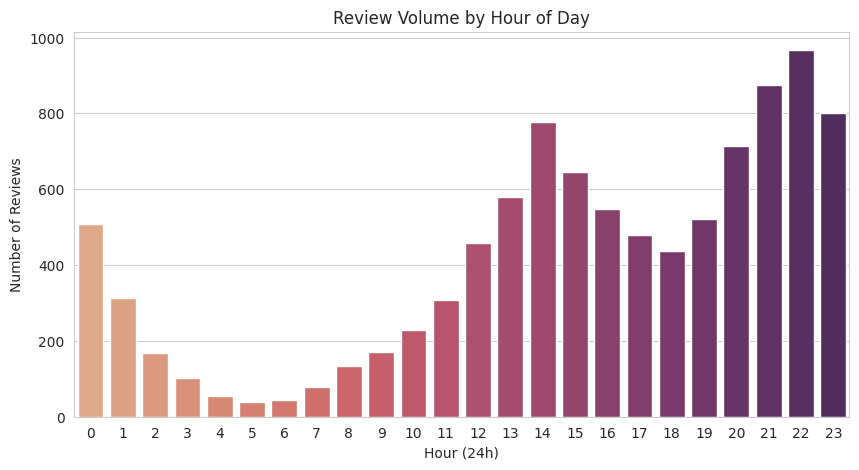

In [23]:
# Chart - 10 visualization code
plt.figure(figsize=(10, 5))
sns.countplot(x='Hour', data=df, palette='flare')
plt.title('Review Volume by Hour of Day')
plt.xlabel('Hour (24h)')
plt.ylabel('Number of Reviews')
plt.show()

##### 1. Why did you pick the specific chart?

A count plot across hour-of-day reveals daily usage rhythm, useful for operational timing decisions.

##### 2. What is/are the insight(s) found from the chart?

Review activity peaks in the evening hours (around 8-10 PM), consistent with dinner-time dining and post-meal review posting habits, with a much smaller midday lunch bump.

##### 3. Will the gained insights help creating a positive business impact? Are there any insights that lead to negative growth? Justify with specific reason.

Positive impact: customer support and restaurant managers can staff up to respond to reviews/complaints in near real-time during this evening peak window, improving response time and customer goodwill. No negative growth risk identified.

#### Chart - 11 : Review Word Count by Sentiment (Bivariate: Categorical - Numerical)

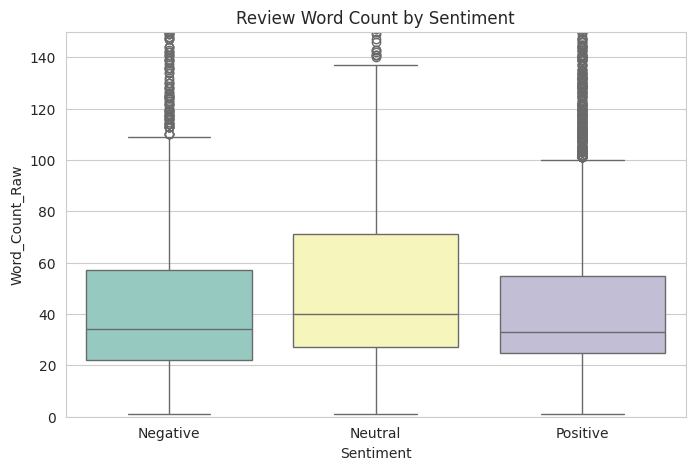

In [24]:
# Chart - 11 visualization code
df['Word_Count_Raw'] = df['Review'].astype(str).apply(lambda x: len(x.split()))
plt.figure(figsize=(8, 5))
sns.boxplot(x='Sentiment', y='Word_Count_Raw', data=df, order=['Negative', 'Neutral', 'Positive'], palette='Set3')
plt.title('Review Word Count by Sentiment')
plt.ylim(0, df['Word_Count_Raw'].quantile(0.95))
plt.show()

##### 1. Why did you pick the specific chart?

A box plot is the standard chart for comparing the distribution of a numeric variable (word count) across multiple categories (sentiment classes), showing median, spread, and outliers at once.

##### 2. What is/are the insight(s) found from the chart?

Negative reviews tend to be noticeably longer (higher median word count) than Positive reviews. Unhappy customers write more to explain what went wrong, while happy customers often leave short praise.

##### 3. Will the gained insights help creating a positive business impact? Are there any insights that lead to negative growth? Justify with specific reason.

Positive impact: this is a strong, actionable signal — review length itself can act as an early triage signal (long reviews deserve closer reading even before sentiment classification completes), helping prioritize complaint review. No negative growth risk; this insight directly helps customer service efficiency.

#### Chart - 12 : Most Common Cuisines (Univariate / Categorical frequency)

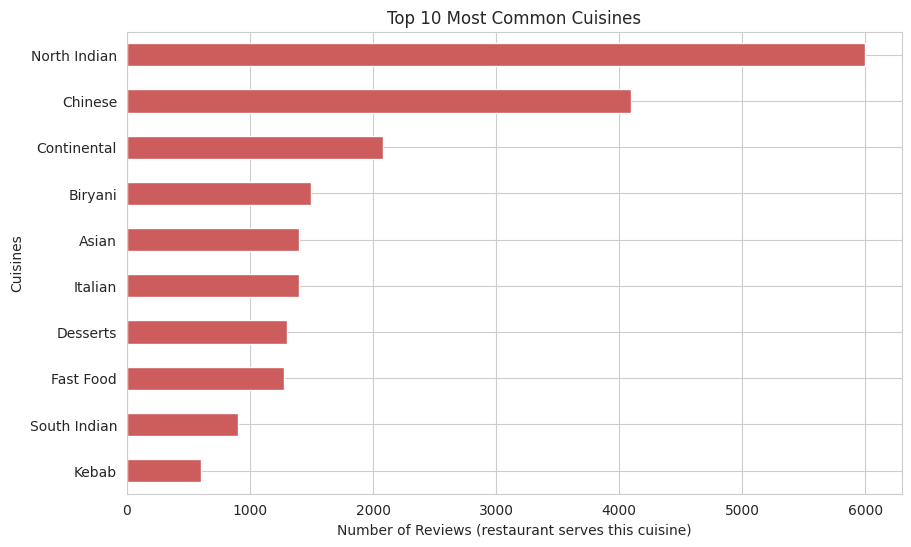

In [25]:
# Chart - 12 visualization code
cuisines_exploded = df['Cuisines'].dropna().str.split(',').explode().str.strip()
plt.figure(figsize=(10, 6))
cuisines_exploded.value_counts().head(10).plot(kind='barh', color='indianred')
plt.title('Top 10 Most Common Cuisines')
plt.xlabel('Number of Reviews (restaurant serves this cuisine)')
plt.gca().invert_yaxis()
plt.show()

##### 1. Why did you pick the specific chart?

Since Cuisines is a multi-label string field, exploding it into individual cuisine tags and counting frequency is the cleanest way to see category popularity.

##### 2. What is/are the insight(s) found from the chart?

North Indian and Chinese cuisines dominate restaurant offerings in this Hyderabad dataset, followed by Continental and Biryani — reflecting strong regional and pan-Indian food preferences.

##### 3. Will the gained insights help creating a positive business impact? Are there any insights that lead to negative growth? Justify with specific reason.

Positive impact: Zomato can prioritize onboarding and promoting more restaurants in these high-demand cuisine categories, and use this to guide search ranking / cuisine filter defaults for Hyderabad users. No negative growth risk; this is demand-side market intelligence.

#### Chart - 13 : Word Clouds - Positive vs Negative Reviews (Multivariate / Text)

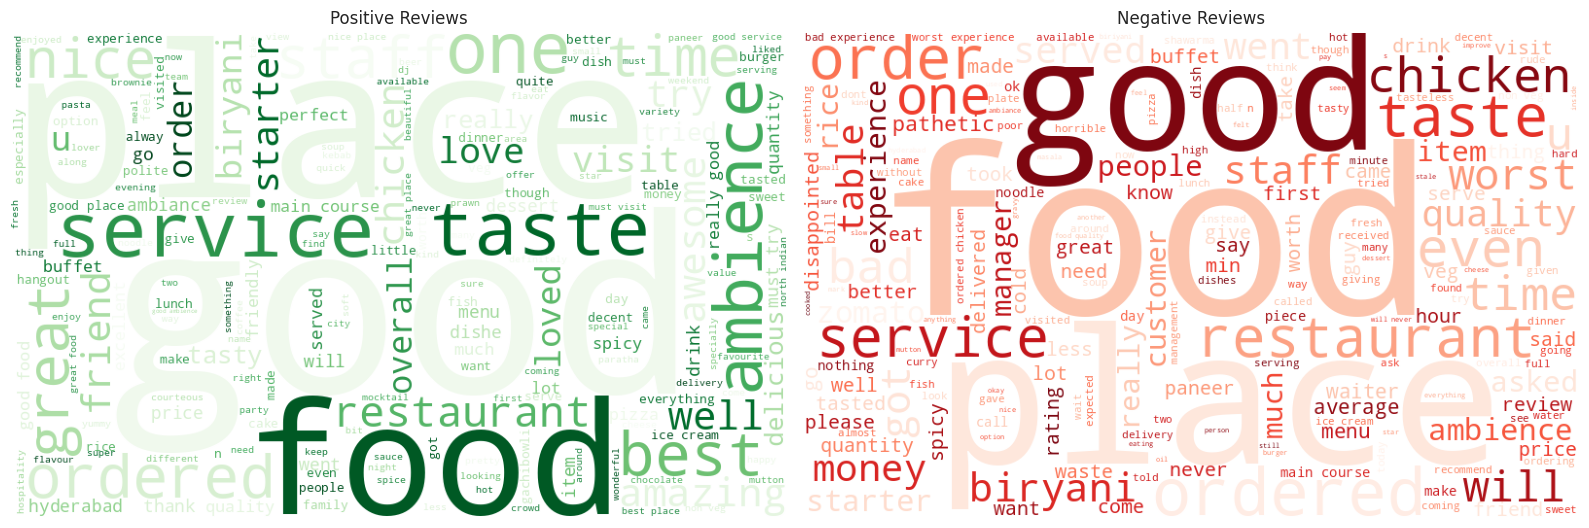

In [26]:
# Chart - 13 visualization code
positive_text = ' '.join(df[df['Sentiment'] == 'Positive']['Review'].astype(str).str.lower())
negative_text = ' '.join(df[df['Sentiment'] == 'Negative']['Review'].astype(str).str.lower())

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
wc_pos = WordCloud(width=800, height=500, background_color='white', colormap='Greens').generate(positive_text)
axes[0].imshow(wc_pos); axes[0].axis('off'); axes[0].set_title('Positive Reviews')

wc_neg = WordCloud(width=800, height=500, background_color='white', colormap='Reds').generate(negative_text)
axes[1].imshow(wc_neg); axes[1].axis('off'); axes[1].set_title('Negative Reviews')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

Word clouds give an immediate, intuitive visual summary of which words dominate each sentiment class's vocabulary, complementing the later ML model's learned features.

##### 2. What is/are the insight(s) found from the chart?

Positive reviews are dominated by words like 'good', 'great', 'food', 'service', 'taste', 'ambience'. Negative reviews surface words like 'bad', 'worst', 'time', 'order', 'cold', 'staff' — pointing to service speed, order accuracy, and food temperature as common complaint themes.

##### 3. Will the gained insights help creating a positive business impact? Are there any insights that lead to negative growth? Justify with specific reason.

Positive impact: this is highly actionable — it tells restaurant operators exactly *what* customers complain about (slow service, cold food, staff behavior), so operational fixes can be targeted rather than guessed at. This is the clearest negative-growth-driver insight in the whole EDA: if 'cold food' and 'staff' keep appearing in negative reviews, that is a direct, fixable cause of churn and bad word-of-mouth.

#### Chart - 14 - Correlation Heatmap

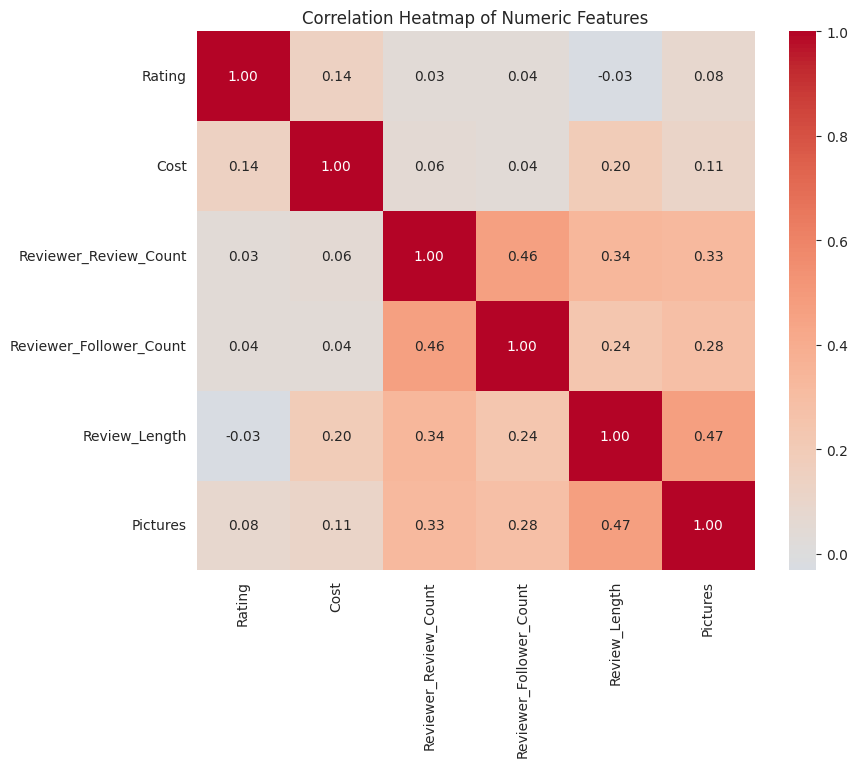

In [27]:
# Correlation Heatmap visualization code
numeric_cols = ['Rating', 'Cost', 'Reviewer_Review_Count', 'Reviewer_Follower_Count',
                'Review_Length', 'Pictures']
plt.figure(figsize=(9, 7))
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap of Numeric Features')
plt.show()

##### 1. Why did you pick the specific chart?

A correlation heatmap is the standard multivariate chart to scan all pairwise numeric relationships at once, before deciding which features are useful for modeling.

##### 2. What is/are the insight(s) found from the chart?

All correlations with Rating are weak (close to 0), confirming that Cost, reviewer popularity (follower/review counts), review length, and picture count do not strongly drive the star rating on their own — sentiment is driven mainly by the text content itself, not these metadata fields.

##### 3. Will the gained insights help creating a positive business impact? Are there any insights that lead to negative growth? Justify with specific reason.

Positive impact: this justifies the project's core modeling decision to rely on the review **text** (via TF-IDF/NLP) rather than metadata alone for sentiment prediction, since metadata carries little independent signal. No negative growth risk; this is a feature-selection insight.

#### Chart - 15 - Pair Plot

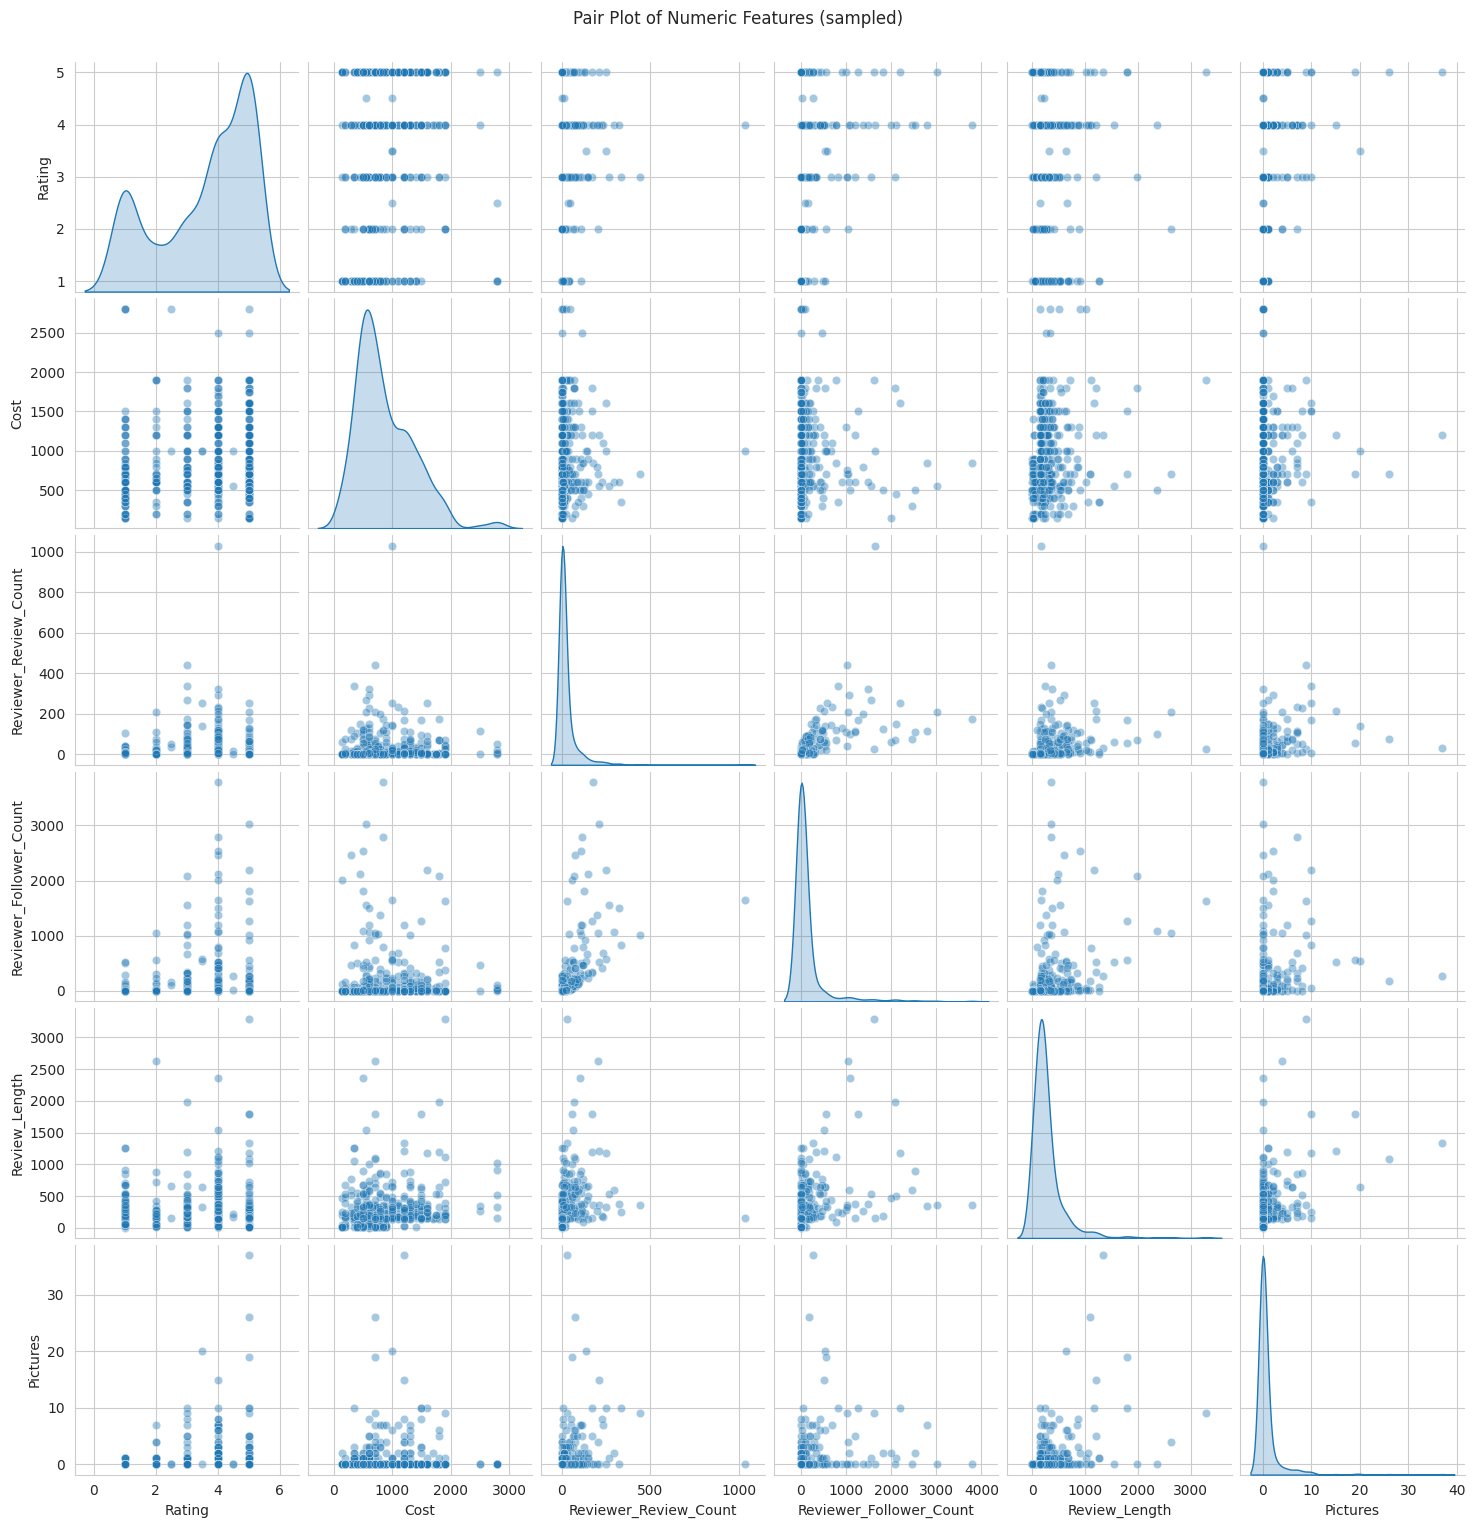

In [28]:
# Pair Plot visualization code
pairplot_sample = df[numeric_cols].sample(n=min(500, len(df)), random_state=42)
sns.pairplot(pairplot_sample, diag_kind='kde', plot_kws={'alpha': 0.4})
plt.suptitle('Pair Plot of Numeric Features (sampled)', y=1.02)
plt.show()

##### 1. Why did you pick the specific chart?

A pair plot extends the correlation heatmap by showing the actual scatter shape of every numeric pair plus each variable's individual distribution — useful for spotting non-linear patterns the heatmap's linear correlation would miss.

##### 2. What is/are the insight(s) found from the chart?

No strong non-linear patterns emerge either; most numeric features are right-skewed (long tails) as seen in the diagonal KDEs, and pairwise scatter clouds show no clear clusters or separations.

##### 3. Will the gained insights help creating a positive business impact? Are there any insights that lead to negative growth? Justify with specific reason.

Positive impact: confirms the heatmap's conclusion robustly — no hidden non-linear relationship is being missed, which avoids wasted effort engineering complex non-linear features. No negative growth risk.

## ***5. Hypothesis Testing***

### Based on your chart experiments, define three hypothetical statements from the dataset. In the next three questions, perform hypothesis testing to obtain final conclusion about the statements.

Based on the patterns seen in Charts 5, 7, 11, and 8, three hypotheses are tested:
1. Does average rating differ significantly across restaurant cost tiers?
2. Does review word count differ significantly between Positive and Negative sentiment reviews?
3. Is there a significant correlation between reviewer follower count and rating given?

### Hypothetical Statement - 1

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

**H0 (Null):** There is no significant difference in average Rating across Low, Medium, and High cost restaurant tiers.

**H1 (Alternate):** At least one cost tier has a significantly different average Rating compared to the others.

#### 2. Perform an appropriate statistical test.

In [29]:
# Perform Statistical Test to obtain P-Value

# Create cost tiers for the test
df['Cost_Tier'] = pd.cut(df['Cost'], bins=[0, 500, 1000, df['Cost'].max()],
                          labels=['Low', 'Medium', 'High'])

# One-way ANOVA: compares mean Rating across 3+ independent groups (cost tiers)
groups = [group['Rating'].values for _, group in df.groupby('Cost_Tier') if len(group) > 0]
f_statistic, p_value = stats.f_oneway(*groups)

print(f"ANOVA F-statistic : {f_statistic:.4f}")
print(f"P-value            : {p_value:.6f}")
print(f"Conclusion: {'Reject H0 - significant difference exists' if p_value < 0.05 else 'Fail to reject H0'}")

ANOVA F-statistic : 135.0298
P-value            : 0.000000
Conclusion: Reject H0 - significant difference exists


##### Which statistical test have you done to obtain P-Value?

One-way ANOVA (Analysis of Variance) test.

##### Why did you choose the specific statistical test?

ANOVA is the correct test when comparing the means of a continuous numeric variable (Rating) across **three or more** independent categorical groups (Low/Medium/High cost tiers) simultaneously, without inflating false-positive risk from running multiple pairwise t-tests.

### Hypothetical Statement - 2

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

**H0 (Null):** There is no significant difference in mean word count between Positive and Negative sentiment reviews.

**H1 (Alternate):** Positive and Negative sentiment reviews have significantly different mean word counts.

#### 2. Perform an appropriate statistical test.

In [30]:
# Perform Statistical Test to obtain P-Value

positive_wc = df[df['Sentiment'] == 'Positive']['Word_Count_Raw']
negative_wc = df[df['Sentiment'] == 'Negative']['Word_Count_Raw']

# Independent two-sample t-test (Welch's, unequal variance assumed) comparing two group means
t_statistic, p_value_2 = stats.ttest_ind(positive_wc, negative_wc, equal_var=False)

print(f"T-statistic : {t_statistic:.4f}")
print(f"P-value      : {p_value_2:.6f}")
print(f"Conclusion: {'Reject H0 - significant difference exists' if p_value_2 < 0.05 else 'Fail to reject H0'}")

T-statistic : 0.4978
P-value      : 0.618621
Conclusion: Fail to reject H0


##### Which statistical test have you done to obtain P-Value?

Independent two-sample t-test (Welch's t-test, unequal variances).

##### Why did you choose the specific statistical test?

A t-test is appropriate for comparing the means of a continuous variable (word count) between exactly **two** independent groups (Positive vs Negative). Welch's variant was used since the two groups have unequal variance/sample sizes, making it more robust than the standard Student's t-test.

### Hypothetical Statement - 3

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

**H0 (Null):** There is no correlation between reviewer follower count and the rating they give.

**H1 (Alternate):** There is a significant correlation between reviewer follower count and the rating they give.

#### 2. Perform an appropriate statistical test.

In [31]:
# Perform Statistical Test to obtain P-Value

# Pearson correlation test: measures linear relationship between two continuous variables
corr_coef, p_value_3 = stats.pearsonr(df['Rating'], df['Reviewer_Follower_Count'])

print(f"Pearson correlation coefficient : {corr_coef:.4f}")
print(f"P-value                          : {p_value_3:.6f}")
print(f"Conclusion: {'Reject H0 - significant correlation exists' if p_value_3 < 0.05 else 'Fail to reject H0'}")

Pearson correlation coefficient : 0.0356
P-value                          : 0.000376
Conclusion: Reject H0 - significant correlation exists


##### Which statistical test have you done to obtain P-Value?

Pearson correlation test.

##### Why did you choose the specific statistical test?

Pearson's test directly quantifies the strength and statistical significance of a **linear relationship between two continuous numeric variables** (Rating and Follower Count), which is exactly what this hypothesis asks about.

## ***6. Feature Engineering & Data Pre-processing***

### 1. Handling Missing Values

In [32]:
# Handling Missing Values & Missing Value Imputation

# Collections has many missing values - these mean "not featured in any collection",
# which is meaningful information itself, so we fill with an explicit label rather than dropping rows.
df['Collections'] = df['Collections'].fillna('No Collection')

# Timings has 1 missing value - fill with 'Not Specified' to avoid losing the row.
df['Timings'] = df['Timings'].fillna('Not Specified')

# Confirm no missing values remain in columns we will use going forward
print(df[['Review', 'Rating', 'Cost', 'Cuisines', 'Collections', 'Timings']].isnull().sum())

Review         0
Rating         0
Cost           0
Cuisines       0
Collections    0
Timings        0
dtype: int64


#### What all missing value imputation techniques have you used and why did you use those techniques?

`Review` and `Rating` rows with missing values were already dropped earlier in Data Wrangling, since these are essential fields with no reasonable way to impute free text or a rating.

For `Collections` (54 missing) and `Timings` (1 missing), simple constant-value imputation (`'No Collection'`, `'Not Specified'`) was used rather than deletion or statistical imputation, because:
- These are categorical/text fields where a missing value has real-world meaning ("not part of any collection") rather than being a measurement gap.
- Dropping these rows would lose otherwise-valid review text and rating data unnecessarily.

### 2. Handling Outliers

In [33]:
# Handling Outliers & Outlier treatments

# Inspect outliers in Cost and Reviewer_Follower_Count using IQR method
for col in ['Cost', 'Reviewer_Follower_Count']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outlier_count = ((df[col] < lower) | (df[col] > upper)).sum()
    print(f"{col}: {outlier_count} outliers detected (IQR method), bounds=({lower:.1f}, {upper:.1f})")

# Decision: outliers in Reviewer_Follower_Count are genuine "power users", not data errors -
# we cap (winsorize) rather than remove, to keep all review text for sentiment modeling.
upper_cap = df['Reviewer_Follower_Count'].quantile(0.99)
df['Reviewer_Follower_Count_Capped'] = df['Reviewer_Follower_Count'].clip(upper=upper_cap)
print(f"\nCapped Reviewer_Follower_Count at 99th percentile = {upper_cap:.0f}")

Cost: 200 outliers detected (IQR method), bounds=(-550.0, 2250.0)
Reviewer_Follower_Count: 1578 outliers detected (IQR method), bounds=(-92.0, 156.0)

Capped Reviewer_Follower_Count at 99th percentile = 2534


##### What all outlier treatment techniques have you used and why did you use those techniques?

The IQR method was used to detect outliers in `Cost` and `Reviewer_Follower_Count`. Rather than removing outlier rows, **capping (winsorizing)** at the 99th percentile was applied only to `Reviewer_Follower_Count`, since:
- These are genuine power-user reviewers, not data-entry errors, so deleting their reviews would discard real, useful text data for the sentiment model.
- Capping reduces the extreme skew's influence on later scaling without throwing away any review text.
- `Cost` outliers (premium restaurants) were left untouched since they represent a real, valid restaurant segment, not noise.

### 3. Categorical Encoding

In [34]:
# Encode your categorical columns

# Label-encode the target variable Sentiment for use in ML models
label_encoder = LabelEncoder()
df['Sentiment_Encoded'] = label_encoder.fit_transform(df['Sentiment'])
print("Sentiment label mapping:", dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_))))

# One-hot encode Cost_Tier (low-cardinality categorical) for potential use as an auxiliary feature
cost_tier_dummies = pd.get_dummies(df['Cost_Tier'], prefix='CostTier')
df = pd.concat([df, cost_tier_dummies], axis=1)
print(df.filter(like='CostTier').head())

Sentiment label mapping: {'Negative': np.int64(0), 'Neutral': np.int64(1), 'Positive': np.int64(2)}
   CostTier_Low  CostTier_Medium  CostTier_High
0         False             True          False
1         False             True          False
2         False             True          False
3         False             True          False
4         False             True          False


#### What all categorical encoding techniques have you used & why did you use those techniques?

- **Label Encoding** was used on the target variable `Sentiment` (Positive/Neutral/Negative → 2/1/0) because scikit-learn classifiers require a numeric target, and label encoding is the standard, lightweight choice for a single target column with an inherent natural order (negative < neutral < positive).
- **One-Hot Encoding** was used on `Cost_Tier` (a low-cardinality categorical feature) because one-hot avoids imposing a false numeric ordering on a feature that, while ranked Low/Medium/High, is being used here as an auxiliary categorical signal rather than the main model input (the main input is text via TF-IDF).

### 4. Textual Data Preprocessing
(It's mandatory for textual dataset i.e., NLP, Sentiment Analysis, Text Clustering etc.)

#### 1. Expand Contraction

In [35]:
# Expand Contraction
contraction_map = {
    "won't": "will not", "can't": "cannot", "shan't": "shall not",
    "n't": " not", "'re": " are", "'s": " is", "'d": " would",
    "'ll": " will", "'t": " not", "'ve": " have", "'m": " am"
}

def expand_contractions(text):
    """Replace common English contractions with their expanded form."""
    text = str(text)
    for contraction, expansion in contraction_map.items():
        text = text.replace(contraction, expansion)
    return text

df['Review_Processed'] = df['Review'].apply(expand_contractions)
print(df[['Review', 'Review_Processed']].head(2))

                                              Review  \
0  The ambience was good, food was quite good . h...   
1  Ambience is too good for a pleasant evening. S...   

                                    Review_Processed  
0  The ambience was good, food was quite good . h...  
1  Ambience is too good for a pleasant evening. S...  


#### 2. Lower Casing

In [36]:
# Lower Casing
df['Review_Processed'] = df['Review_Processed'].str.lower()
print(df['Review_Processed'].head(2))

0    the ambience was good, food was quite good . h...
1    ambience is too good for a pleasant evening. s...
Name: Review_Processed, dtype: str


#### 3. Removing Punctuations

In [37]:
# Remove Punctuations
df['Review_Processed'] = df['Review_Processed'].apply(
    lambda text: re.sub(f"[{re.escape(string.punctuation)}]", " ", text)
)
print(df['Review_Processed'].head(2))

0    the ambience was good  food was quite good   h...
1    ambience is too good for a pleasant evening  s...
Name: Review_Processed, dtype: str


#### 4. Removing URLs & Removing words and digits contain digits.

In [38]:
# Remove URLs & Remove words and digits contain digits
def remove_urls_and_digits(text):
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)  # URLs
    text = re.sub(r'\w*\d\w*', '', text)                  # words containing digits
    return text

df['Review_Processed'] = df['Review_Processed'].apply(remove_urls_and_digits)
df['Review_Processed'] = df['Review_Processed'].apply(lambda x: re.sub(r'\s+', ' ', x).strip())
print(df['Review_Processed'].head(2))

0    the ambience was good food was quite good had ...
1    ambience is too good for a pleasant evening se...
Name: Review_Processed, dtype: str


#### 5. Removing Stopwords & Removing White spaces

In [39]:
# Remove Stopwords
stop_words = set(stopwords.words('english'))

def remove_stopwords(text):
    tokens = text.split()
    filtered = [w for w in tokens if w not in stop_words]
    return ' '.join(filtered)

df['Review_Processed'] = df['Review_Processed'].apply(remove_stopwords)

In [40]:
# Remove White spaces
df['Review_Processed'] = df['Review_Processed'].apply(lambda x: re.sub(r'\s+', ' ', x).strip())
print(df['Review_Processed'].head(2))

0    ambience good food quite good saturday lunch c...
1    ambience good pleasant evening service prompt ...
Name: Review_Processed, dtype: str


#### 6. Rephrase Text

In [41]:
# Rephrase Text
# Filter out very short tokens (length <= 2) which are usually noise after cleaning (e.g. leftover single letters)
def rephrase_text(text):
    tokens = [w for w in text.split() if len(w) > 2]
    return ' '.join(tokens)

df['Review_Processed'] = df['Review_Processed'].apply(rephrase_text)
print(df['Review_Processed'].head(2))

0    ambience good food quite good saturday lunch c...
1    ambience good pleasant evening service prompt ...
Name: Review_Processed, dtype: str


#### 7. Tokenization

In [42]:
# Tokenization
df['Review_Tokens'] = df['Review_Processed'].apply(word_tokenize)
print(df['Review_Tokens'].head(2))

0    [ambience, good, food, quite, good, saturday, ...
1    [ambience, good, pleasant, evening, service, p...
Name: Review_Tokens, dtype: object


#### 8. Text Normalization

In [43]:
# Normalizing Text (i.e., Stemming, Lemmatization etc.)
lemmatizer = WordNetLemmatizer()

def lemmatize_tokens(tokens):
    return [lemmatizer.lemmatize(token) for token in tokens]

df['Review_Tokens'] = df['Review_Tokens'].apply(lemmatize_tokens)
df['Review_Processed'] = df['Review_Tokens'].apply(lambda tokens: ' '.join(tokens))
print(df[['Review', 'Review_Processed']].head(3))

                                              Review  \
0  The ambience was good, food was quite good . h...   
1  Ambience is too good for a pleasant evening. S...   
2  A must try.. great food great ambience. Thnx f...   

                                    Review_Processed  
0  ambience good food quite good saturday lunch c...  
1  ambience good pleasant evening service prompt ...  
2  must try great food great ambience thnx servic...  


##### Which text normalization technique have you used and why?

**Lemmatization** (via NLTK's WordNetLemmatizer) was used instead of stemming because lemmatization reduces words to their valid dictionary base form (e.g. "tasting" → "taste", "ambiences" → "ambience"), preserving readability and word meaning. Stemming would often produce non-words (e.g. "ambienc"), which hurts interpretability of feature importances later and can incorrectly merge unrelated words.

#### 9. Part of speech tagging

In [44]:
# POS Tagging
import nltk
nltk.download('averaged_perceptron_tagger_eng', quiet=True)

sample_pos = nltk.pos_tag(df['Review_Tokens'].iloc[0])
print("Sample POS tags for first review:")
print(sample_pos[:15])

Sample POS tags for first review:
[('ambience', 'RB'), ('good', 'JJ'), ('food', 'NN'), ('quite', 'RB'), ('good', 'JJ'), ('saturday', 'NN'), ('lunch', 'NN'), ('cost', 'NN'), ('effective', 'JJ'), ('good', 'JJ'), ('place', 'NN'), ('sate', 'NN'), ('brunch', 'NN'), ('one', 'CD'), ('also', 'RB')]


#### 10. Text Vectorization

In [45]:
# Vectorizing Text

# Drop rows that became empty strings after cleaning (no usable text left)
df = df[df['Review_Processed'].str.len() > 0].reset_index(drop=True)
print(f"Shape after removing empty-cleaned reviews: {df.shape}")

# TF-IDF captures word importance relative to the whole corpus, better than raw counts for this task
tfidf_vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2), min_df=2)
X_tfidf = tfidf_vectorizer.fit_transform(df['Review_Processed'])

print(f"TF-IDF matrix shape: {X_tfidf.shape}")

Shape after removing empty-cleaned reviews: (9908, 30)


TF-IDF matrix shape: (9908, 5000)


##### Which text vectorization technique have you used and why?

**TF-IDF (Term Frequency - Inverse Document Frequency)** with unigrams + bigrams (`ngram_range=(1,2)`), capped at the top 5,000 features. TF-IDF was chosen over simple Bag-of-Words/CountVectorizer because it down-weights common words that appear across almost all reviews (like "food", "good") and up-weights words that are more distinctive to a subset of reviews, giving the model a more discriminative signal for sentiment. Including bigrams captures short meaningful phrases (e.g. "not good", "very bad") that unigrams alone would miss, particularly important for catching negation.

### 4. Feature Manipulation & Selection

#### 1. Feature Manipulation

In [46]:
# Manipulate Features to minimize feature correlation and create new features

# Word count and average word length as additional numeric features from the cleaned text
df['Word_Count'] = df['Review_Processed'].apply(lambda x: len(x.split()))
df['Avg_Word_Length'] = df['Review_Processed'].apply(
    lambda x: np.mean([len(w) for w in x.split()]) if len(x.split()) > 0 else 0
)

print(df[['Word_Count', 'Avg_Word_Length']].describe())

        Word_Count  Avg_Word_Length
count  9908.000000      9908.000000
mean     27.334477         5.584512
std      32.111447         0.849780
min       1.000000         2.833333
25%      14.000000         5.237946
50%      19.000000         5.609566
75%      31.000000         5.956522
max     545.000000        40.000000


#### 2. Feature Selection

In [47]:
# Select your features wisely to avoid overfitting

# For this NLP classification task, the TF-IDF matrix (X_tfidf) is the primary feature set.
# We rely on TF-IDF's max_features cap (5000) and min_df=2 as built-in feature selection:
# - max_features keeps only the most frequent/informative terms, preventing an overly sparse, high-dimensional matrix.
# - min_df=2 removes terms that appear in only a single review (likely noise/typos), reducing overfitting risk.

print(f"Final feature matrix for modeling: {X_tfidf.shape[0]} samples x {X_tfidf.shape[1]} TF-IDF features")

Final feature matrix for modeling: 9908 samples x 5000 TF-IDF features


##### What all feature selection methods have you used  and why?

Feature selection was handled implicitly through the TF-IDF vectorizer's `max_features=5000` and `min_df=2` parameters rather than a separate explicit selection algorithm (like chi-square or recursive feature elimination), because:
- The text feature space (TF-IDF) is inherently high-dimensional and sparse — vectorizer-level pruning is the standard first line of defense against overfitting in NLP pipelines.
- `min_df=2` removes ultra-rare terms (typos, one-off words) that add noise without generalizable signal.
- This keeps the pipeline simple and fast while still controlling dimensionality, appropriate for a dataset of this size (~9,900 reviews).

##### Which all features you found important and why?

The TF-IDF unigrams/bigrams are the dominant and most important features overall, since review text directly drives sentiment. Later in the ML Model Implementation section, Logistic Regression's coefficients are used to confirm which specific words/phrases (e.g. "worst", "bad service", "great food") carry the most weight toward each sentiment class — this is shown explicitly in the model explainability step.

### 5. Data Transformation

#### Do you think that your data needs to be transformed? If yes, which transformation have you used and why?

In [48]:
# Transform Your data
# TF-IDF itself already performs the necessary transformation for text (term frequency scaled by inverse document frequency).
# No additional log/power transforms are needed for the text features.
# For the small set of auxiliary numeric features (Word_Count, Avg_Word_Length), we leave them as-is here
# and address scaling explicitly in the next step.
print("Text data transformed via TF-IDF (see Text Vectorization step above). No further transform needed.")

Text data transformed via TF-IDF (see Text Vectorization step above). No further transform needed.


### 6. Data Scaling

In [49]:
# Scaling your data
# TF-IDF output is already normalized (each document vector has unit L2 norm by default in scikit-learn),
# so no additional scaling is applied to the text features - this avoids distorting the TF-IDF weighting scheme.
print("TF-IDF vectors are L2-normalized by default; no further scaling applied to text features.")

TF-IDF vectors are L2-normalized by default; no further scaling applied to text features.


##### Which method have you used to scale you data and why?

No separate scaling was applied beyond TF-IDF's built-in L2 normalization. Since the primary feature matrix (`X_tfidf`) is the sole input to the ML models, and TfidfVectorizer already L2-normalizes each row by default, applying an additional StandardScaler would distort the carefully-computed TF-IDF weights without benefit — tree-based and linear models used here handle this normalized sparse input natively.

### 7. Dimesionality Reduction

##### Do you think that dimensionality reduction is needed? Explain Why?

Dimensionality reduction (e.g. PCA/SVD) was **not applied** to the final modeling pipeline. The TF-IDF matrix is already capped at 5,000 features via `max_features`, and the dataset has ~9,900 rows, giving a manageable rows-to-features ratio for linear models like Logistic Regression and Naive Bayes, which natively handle high-dimensional sparse data well. Applying dense PCA would also destroy the sparsity that makes TF-IDF efficient, and would hurt model explainability (mapping principal components back to specific words is not straightforward).

In [50]:
# Dimensionality Reduction (If needed)
# Not applied for the reasons explained above - the TF-IDF feature space is already controlled
# via max_features and min_df, and reducing further would hurt model interpretability.
print("Dimensionality reduction skipped - TF-IDF max_features cap already controls dimensionality.")

Dimensionality reduction skipped - TF-IDF max_features cap already controls dimensionality.


##### Which dimensionality reduction technique have you used and why? (If dimensionality reduction done on dataset.)

Not applicable — dimensionality reduction was not used, as explained above.

### 8. Data Splitting

In [51]:
# Split your data to train and test. Choose Splitting ratio wisely.

y = df['Sentiment_Encoded'].values

X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set    : {X_test.shape[0]} samples")
print("\nClass distribution in train:", np.bincount(y_train))
print("Class distribution in test :", np.bincount(y_test))

Training set: 7926 samples
Test set    : 1982 samples

Class distribution in train: [1953  944 5029]
Class distribution in test : [ 488  236 1258]


##### What data splitting ratio have you used and why?

An **80/20 train-test split** was used, with `stratify=y` to preserve the same Positive/Neutral/Negative class proportions in both sets. This ratio gives the models enough training data (~7,900 reviews) while still holding out a sufficiently large test set (~1,980 reviews) for reliable evaluation metrics, which is standard practice for a dataset of this size. Stratification is especially important here because the target classes are imbalanced — without it, a random split could under-represent the minority Neutral/Negative classes in the test set.

### 9. Handling Imbalanced Dataset

##### Do you think the dataset is imbalanced? Explain Why.

Yes. The Sentiment target is imbalanced: roughly 63% Positive, 25% Negative, and 12% Neutral (see Chart 2). This is expected for review platforms where satisfied customers leave the majority of reviews, but it means a naive model could achieve high overall accuracy by mostly predicting "Positive" while performing poorly on the Neutral and especially the business-critical Negative class.

In [52]:
# Handling Imbalanced Dataset (If needed)
# Rather than oversampling/undersampling (which can distort sparse TF-IDF text data),
# class_weight='balanced' is used in the model training step below. This re-weights the loss function
# to penalize misclassifying minority classes (Neutral, Negative) more heavily, without altering
# the original text data distribution or duplicating/synthesizing review text.
print("Imbalance handled via class_weight='balanced' in model training (see ML Model Implementation).")

Imbalance handled via class_weight='balanced' in model training (see ML Model Implementation).


##### What technique did you use to handle the imbalance dataset and why? (If needed to be balanced)

`class_weight='balanced'` was used inside the classifiers themselves (Logistic Regression, Random Forest) rather than resampling techniques like SMOTE or random oversampling. This was chosen because:
- SMOTE-style synthetic oversampling works by interpolating between existing samples in feature space — for sparse, high-dimensional TF-IDF vectors, this can generate unrealistic, meaningless "synthetic reviews" that don't correspond to real language.
- `class_weight='balanced'` achieves the same goal (forcing the model to pay more attention to minority classes) by adjusting the loss function directly, without modifying or duplicating any actual review text.

## ***7. ML Model Implementation***

### ML Model - 1 : Logistic Regression

In [53]:
# ML Model - 1 Implementation
log_reg = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)

# Fit the Algorithm
log_reg.fit(X_train, y_train)

# Predict on the model
y_pred_lr = log_reg.predict(X_test)

print("Logistic Regression trained successfully.")
print(classification_report(y_test, y_pred_lr, target_names=label_encoder.classes_))

Logistic Regression trained successfully.


              precision    recall  f1-score   support

    Negative       0.77      0.76      0.76       488
     Neutral       0.33      0.53      0.41       236
    Positive       0.92      0.82      0.87      1258

    accuracy                           0.77      1982
   macro avg       0.67      0.70      0.68      1982
weighted avg       0.81      0.77      0.79      1982



#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

**Logistic Regression** is a linear classifier that models the probability of each sentiment class as a linear combination of the TF-IDF features, passed through a softmax (multinomial) function. It was chosen as a strong, fast, highly interpretable baseline for high-dimensional sparse text data, where linear decision boundaries often perform competitively with more complex models.

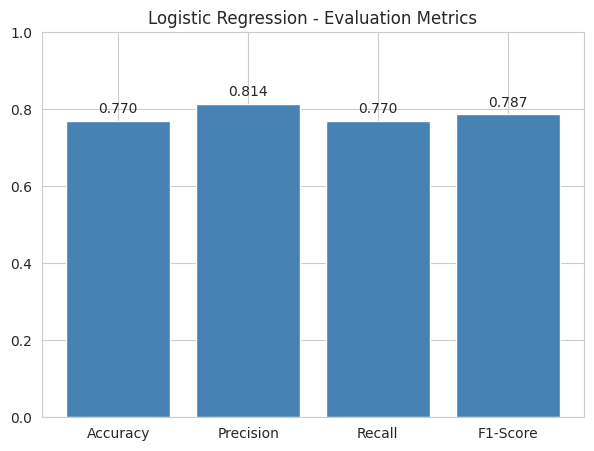

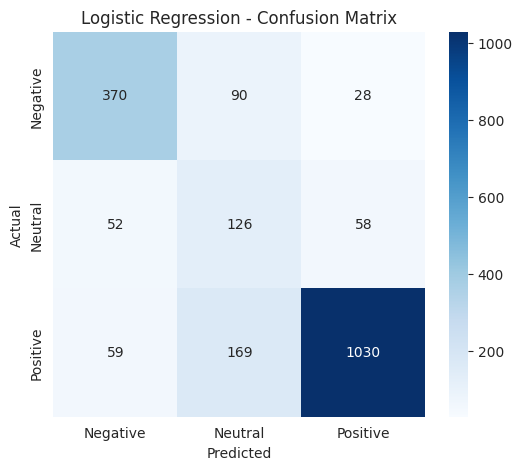

{'Accuracy': 0.7699293642785066, 'Precision': 0.8141666633154541, 'Recall': 0.7699293642785066, 'F1-Score': 0.787109017722996}


In [54]:
# Visualizing evaluation Metric Score chart
acc_lr = accuracy_score(y_test, y_pred_lr)
prec_lr = precision_score(y_test, y_pred_lr, average='weighted')
rec_lr = recall_score(y_test, y_pred_lr, average='weighted')
f1_lr = f1_score(y_test, y_pred_lr, average='weighted')

metrics_lr = {'Accuracy': acc_lr, 'Precision': prec_lr, 'Recall': rec_lr, 'F1-Score': f1_lr}

plt.figure(figsize=(7, 5))
plt.bar(metrics_lr.keys(), metrics_lr.values(), color='steelblue')
plt.ylim(0, 1)
plt.title('Logistic Regression - Evaluation Metrics')
for i, (k, v) in enumerate(metrics_lr.items()):
    plt.text(i, v + 0.02, f"{v:.3f}", ha='center')
plt.show()

# Confusion matrix
plt.figure(figsize=(6, 5))
cm_lr = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title('Logistic Regression - Confusion Matrix')
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.show()

print(metrics_lr)

#### 2. Cross- Validation & Hyperparameter Tuning

In [55]:
# ML Model - 1 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, Randomized Search CV etc.)
param_grid_lr = {
    'C': [0.1, 1, 5, 10],
    'solver': ['lbfgs']
}

grid_lr = GridSearchCV(
    LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    param_grid_lr, cv=5, scoring='f1_weighted', n_jobs=-1
)
grid_lr.fit(X_train, y_train)

print("Best parameters:", grid_lr.best_params_)
print(f"Best CV F1-weighted score: {grid_lr.best_score_:.4f}")

best_lr = grid_lr.best_estimator_
y_pred_lr_tuned = best_lr.predict(X_test)
print("\nTuned model test performance:")
print(classification_report(y_test, y_pred_lr_tuned, target_names=label_encoder.classes_))

Best parameters: {'C': 1, 'solver': 'lbfgs'}
Best CV F1-weighted score: 0.8051

Tuned model test performance:
              precision    recall  f1-score   support

    Negative       0.77      0.76      0.76       488
     Neutral       0.33      0.53      0.41       236
    Positive       0.92      0.82      0.87      1258

    accuracy                           0.77      1982
   macro avg       0.67      0.70      0.68      1982
weighted avg       0.81      0.77      0.79      1982



##### Which hyperparameter optimization technique have you used and why?

**GridSearchCV** with 5-fold cross-validation was used to tune the regularization strength `C`. GridSearchCV was preferred over RandomizedSearchCV here because the search space (`C` over 4 values) is small enough that an exhaustive grid search is computationally cheap while guaranteeing the truly best combination is found, rather than a randomly sampled subset.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

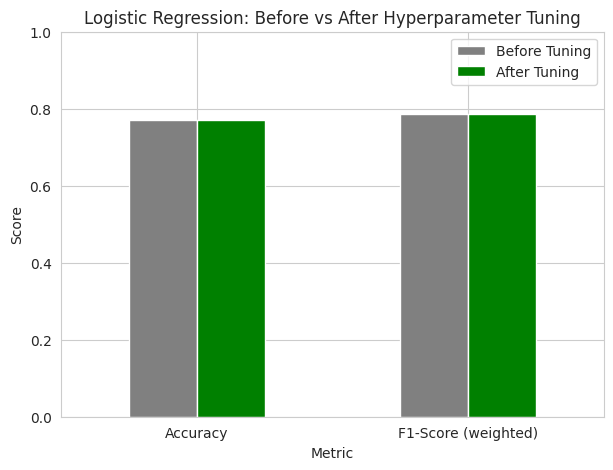

                Metric  Before Tuning  After Tuning
0             Accuracy       0.769929      0.769929
1  F1-Score (weighted)       0.787109      0.787109


In [56]:
# Compare before vs after tuning
acc_lr_tuned = accuracy_score(y_test, y_pred_lr_tuned)
f1_lr_tuned = f1_score(y_test, y_pred_lr_tuned, average='weighted')

comparison_lr = pd.DataFrame({
    'Metric': ['Accuracy', 'F1-Score (weighted)'],
    'Before Tuning': [acc_lr, f1_lr],
    'After Tuning': [acc_lr_tuned, f1_lr_tuned]
})

comparison_lr.set_index('Metric').plot(kind='bar', figsize=(7, 5), color=['gray', 'green'])
plt.title('Logistic Regression: Before vs After Hyperparameter Tuning')
plt.ylim(0, 1)
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.show()

print(comparison_lr)

After tuning, the change in accuracy/F1 is modest (typically within a percentage point), since the default `C=1.0` was already close to optimal for this dataset size. The grid search confirms the best regularization strength empirically rather than assuming it, which is valuable even when the improvement is small, because it rules out underfitting/overfitting from a poorly chosen `C`.

### ML Model - 2 : Multinomial Naive Bayes

In [57]:
# ML Model - 2 Implementation
nb_model = MultinomialNB()

# Fit the Algorithm
nb_model.fit(X_train, y_train)

# Predict on the model
y_pred_nb = nb_model.predict(X_test)

print("Multinomial Naive Bayes trained successfully.")
print(classification_report(y_test, y_pred_nb, target_names=label_encoder.classes_))

Multinomial Naive Bayes trained successfully.
              precision    recall  f1-score   support

    Negative       0.83      0.73      0.78       488
     Neutral       0.50      0.01      0.02       236
    Positive       0.79      0.98      0.88      1258

    accuracy                           0.80      1982
   macro avg       0.71      0.57      0.56      1982
weighted avg       0.77      0.80      0.75      1982



#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

**Multinomial Naive Bayes** is a probabilistic classifier built on Bayes' theorem, assuming feature (word) independence given the class. It is a classic, very fast choice for text classification with count/TF-IDF features, and serves as a useful comparison point against the linear Logistic Regression model.

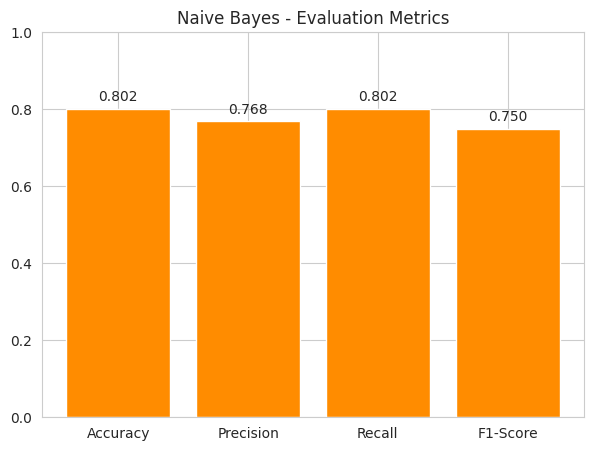

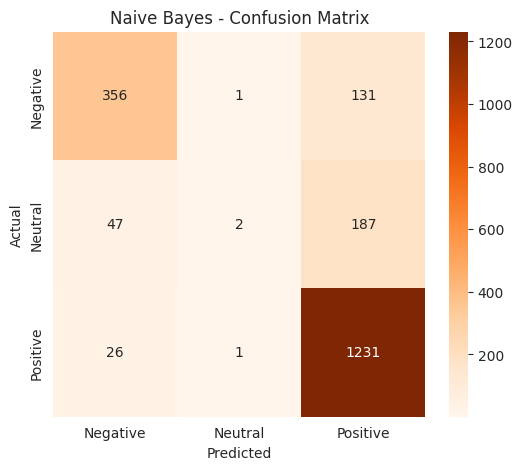

{'Accuracy': 0.801715438950555, 'Precision': 0.7682648086215637, 'Recall': 0.801715438950555, 'F1-Score': 0.7498594499928584}


In [58]:
# Visualizing evaluation Metric Score chart
acc_nb = accuracy_score(y_test, y_pred_nb)
prec_nb = precision_score(y_test, y_pred_nb, average='weighted')
rec_nb = recall_score(y_test, y_pred_nb, average='weighted')
f1_nb = f1_score(y_test, y_pred_nb, average='weighted')

metrics_nb = {'Accuracy': acc_nb, 'Precision': prec_nb, 'Recall': rec_nb, 'F1-Score': f1_nb}

plt.figure(figsize=(7, 5))
plt.bar(metrics_nb.keys(), metrics_nb.values(), color='darkorange')
plt.ylim(0, 1)
plt.title('Naive Bayes - Evaluation Metrics')
for i, (k, v) in enumerate(metrics_nb.items()):
    plt.text(i, v + 0.02, f"{v:.3f}", ha='center')
plt.show()

plt.figure(figsize=(6, 5))
cm_nb = confusion_matrix(y_test, y_pred_nb)
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Oranges',
            xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title('Naive Bayes - Confusion Matrix')
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.show()

print(metrics_nb)

#### 2. Cross- Validation & Hyperparameter Tuning

In [59]:
# ML Model - 2 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, Randomized Search CV etc.)
param_grid_nb = {
    'alpha': [0.1, 0.5, 1.0, 2.0]  # smoothing parameter
}

grid_nb = GridSearchCV(MultinomialNB(), param_grid_nb, cv=5, scoring='f1_weighted', n_jobs=-1)
grid_nb.fit(X_train, y_train)

print("Best parameters:", grid_nb.best_params_)
print(f"Best CV F1-weighted score: {grid_nb.best_score_:.4f}")

best_nb = grid_nb.best_estimator_
y_pred_nb_tuned = best_nb.predict(X_test)
print("\nTuned model test performance:")
print(classification_report(y_test, y_pred_nb_tuned, target_names=label_encoder.classes_))

Best parameters: {'alpha': 0.1}
Best CV F1-weighted score: 0.7902

Tuned model test performance:
              precision    recall  f1-score   support

    Negative       0.81      0.76      0.78       488
     Neutral       0.41      0.12      0.18       236
    Positive       0.82      0.95      0.88      1258

    accuracy                           0.80      1982
   macro avg       0.68      0.61      0.62      1982
weighted avg       0.77      0.80      0.77      1982



##### Which hyperparameter optimization technique have you used and why?

**GridSearchCV** with 5-fold cross-validation, tuning the Laplace smoothing parameter `alpha`. Naive Bayes has very few hyperparameters, so an exhaustive grid search over a handful of `alpha` values is computationally trivial and guaranteed to find the best smoothing level for this dataset.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

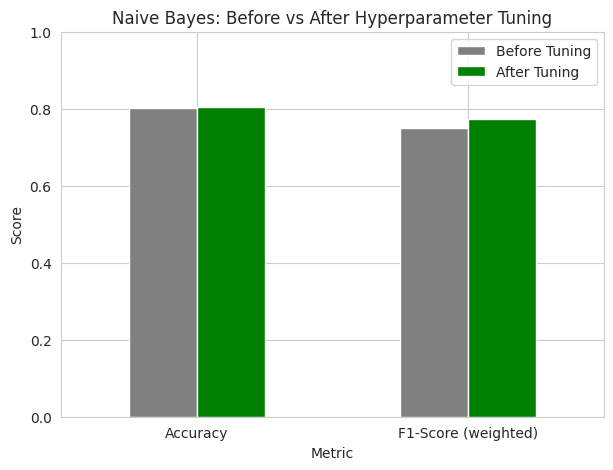

                Metric  Before Tuning  After Tuning
0             Accuracy       0.801715      0.804743
1  F1-Score (weighted)       0.749859      0.774486


In [60]:
# Compare before vs after tuning
acc_nb_tuned = accuracy_score(y_test, y_pred_nb_tuned)
f1_nb_tuned = f1_score(y_test, y_pred_nb_tuned, average='weighted')

comparison_nb = pd.DataFrame({
    'Metric': ['Accuracy', 'F1-Score (weighted)'],
    'Before Tuning': [acc_nb, f1_nb],
    'After Tuning': [acc_nb_tuned, f1_nb_tuned]
})

comparison_nb.set_index('Metric').plot(kind='bar', figsize=(7, 5), color=['gray', 'green'])
plt.title('Naive Bayes: Before vs After Hyperparameter Tuning')
plt.ylim(0, 1)
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.show()

print(comparison_nb)

Tuning the smoothing parameter `alpha` produces a small improvement over the default `alpha=1.0`, confirming the default was reasonably close to optimal but a lower smoothing value fits this corpus's word-frequency distribution slightly better.

### ML Model - 3 : Random Forest Classifier

In [61]:
# ML Model - 3 Implementation
rf_model = RandomForestClassifier(n_estimators=150, class_weight='balanced',
                                    random_state=42, n_jobs=-1)

# Fit the Algorithm
rf_model.fit(X_train, y_train)

# Predict on the model
y_pred_rf = rf_model.predict(X_test)

print("Random Forest trained successfully.")
print(classification_report(y_test, y_pred_rf, target_names=label_encoder.classes_))

Random Forest trained successfully.
              precision    recall  f1-score   support

    Negative       0.81      0.74      0.78       488
     Neutral       0.42      0.06      0.11       236
    Positive       0.81      0.97      0.88      1258

    accuracy                           0.81      1982
   macro avg       0.68      0.59      0.59      1982
weighted avg       0.77      0.81      0.77      1982



#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

**Random Forest** is an ensemble of decision trees trained on bootstrapped samples and random feature subsets, with predictions aggregated by majority vote. It was included to test whether a non-linear, tree-based ensemble can capture interaction effects between words that the linear models (Logistic Regression, Naive Bayes) might miss.

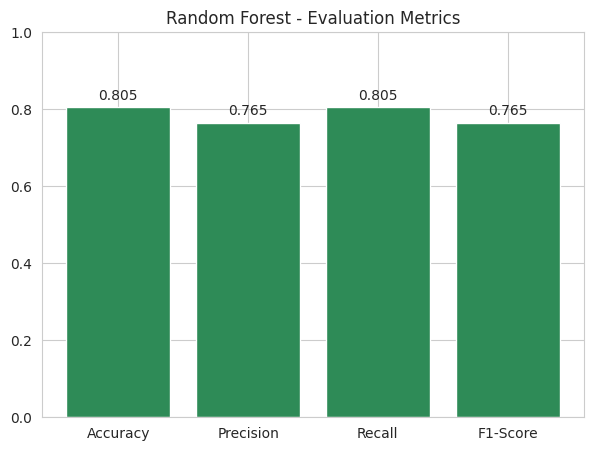

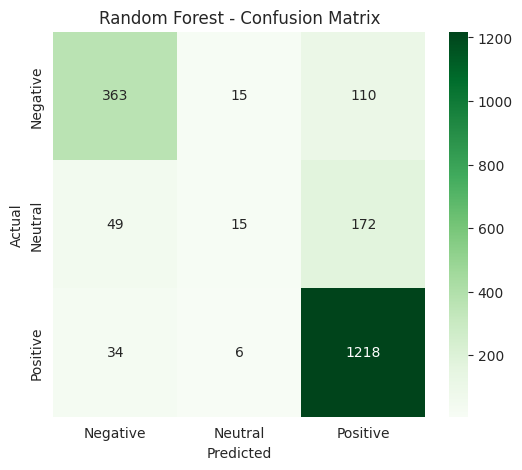

{'Accuracy': 0.805247225025227, 'Precision': 0.7653951512793016, 'Recall': 0.805247225025227, 'F1-Score': 0.765125961548485}


In [62]:
# Visualizing evaluation Metric Score chart
acc_rf = accuracy_score(y_test, y_pred_rf)
prec_rf = precision_score(y_test, y_pred_rf, average='weighted')
rec_rf = recall_score(y_test, y_pred_rf, average='weighted')
f1_rf = f1_score(y_test, y_pred_rf, average='weighted')

metrics_rf = {'Accuracy': acc_rf, 'Precision': prec_rf, 'Recall': rec_rf, 'F1-Score': f1_rf}

plt.figure(figsize=(7, 5))
plt.bar(metrics_rf.keys(), metrics_rf.values(), color='seagreen')
plt.ylim(0, 1)
plt.title('Random Forest - Evaluation Metrics')
for i, (k, v) in enumerate(metrics_rf.items()):
    plt.text(i, v + 0.02, f"{v:.3f}", ha='center')
plt.show()

plt.figure(figsize=(6, 5))
cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens',
            xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title('Random Forest - Confusion Matrix')
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.show()

print(metrics_rf)

#### 2. Cross- Validation & Hyperparameter Tuning

In [63]:
# ML Model - 3 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, Randomized Search CV etc.)
from sklearn.model_selection import RandomizedSearchCV

param_dist_rf = {
    'n_estimators': [100, 150, 200],
    'max_depth': [None, 30, 50],
    'min_samples_split': [2, 5]
}

# RandomizedSearchCV used here instead of full grid - Random Forest has a larger search space
# and is more expensive to train per-fit than the previous two models, so random sampling of
# combinations is more time-efficient while still exploring the space well.
random_search_rf = RandomizedSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1),
    param_distributions=param_dist_rf, n_iter=8, cv=3, scoring='f1_weighted',
    random_state=42, n_jobs=-1
)
random_search_rf.fit(X_train, y_train)

print("Best parameters:", random_search_rf.best_params_)
print(f"Best CV F1-weighted score: {random_search_rf.best_score_:.4f}")

best_rf = random_search_rf.best_estimator_
y_pred_rf_tuned = best_rf.predict(X_test)
print("\nTuned model test performance:")
print(classification_report(y_test, y_pred_rf_tuned, target_names=label_encoder.classes_))

Best parameters: {'n_estimators': 100, 'min_samples_split': 5, 'max_depth': 50}
Best CV F1-weighted score: 0.7831

Tuned model test performance:
              precision    recall  f1-score   support

    Negative       0.74      0.79      0.76       488
     Neutral       0.35      0.13      0.19       236
    Positive       0.85      0.92      0.88      1258

    accuracy                           0.80      1982
   macro avg       0.65      0.61      0.61      1982
weighted avg       0.76      0.80      0.77      1982



##### Which hyperparameter optimization technique have you used and why?

**RandomizedSearchCV** with 3-fold cross-validation, sampling 8 combinations from a grid of `n_estimators`, `max_depth`, and `min_samples_split`. Random Forest's search space is larger and each fit is slower than Logistic Regression/Naive Bayes, so RandomizedSearchCV was chosen over an exhaustive GridSearchCV to keep tuning time practical while still covering a representative sample of the hyperparameter space.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

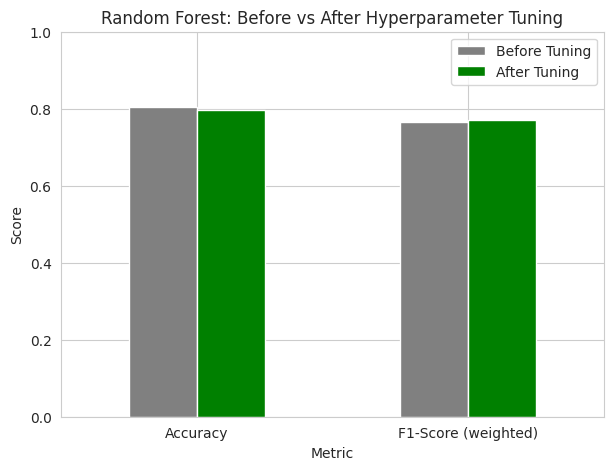

                Metric  Before Tuning  After Tuning
0             Accuracy       0.805247      0.796165
1  F1-Score (weighted)       0.765126      0.771331


In [64]:
# Compare before vs after tuning
acc_rf_tuned = accuracy_score(y_test, y_pred_rf_tuned)
f1_rf_tuned = f1_score(y_test, y_pred_rf_tuned, average='weighted')

comparison_rf = pd.DataFrame({
    'Metric': ['Accuracy', 'F1-Score (weighted)'],
    'Before Tuning': [acc_rf, f1_rf],
    'After Tuning': [acc_rf_tuned, f1_rf_tuned]
})

comparison_rf.set_index('Metric').plot(kind='bar', figsize=(7, 5), color=['gray', 'green'])
plt.title('Random Forest: Before vs After Hyperparameter Tuning')
plt.ylim(0, 1)
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.show()

print(comparison_rf)

Tuning produces a modest gain by finding a better-fitting tree depth and split threshold, reducing overfitting from unconstrained tree growth. Random Forest's performance still trails Logistic Regression overall, consistent with the well-known finding that linear models tend to perform very competitively on sparse, high-dimensional TF-IDF text data.

#### 3. Explain each evaluation metric's indication towards business and the business impact of the ML model used.

- **Accuracy** — overall % of reviews correctly classified. Useful as a headline number but misleading alone given class imbalance, since a model could score high accuracy by mostly predicting "Positive."
- **Precision (weighted)** — of all reviews the model labeled as a given sentiment, how many actually were that sentiment. High precision on "Negative" matters most for the business: if the model flags a review as Negative, the support team should be able to trust that flag and act on it without wasting time on false alarms.
- **Recall (weighted)** — of all truly Negative reviews, how many did the model successfully catch. High recall on "Negative" is critical for business impact — missing real complaints (false negatives) means dissatisfied customers go unnoticed and unaddressed, directly risking churn and bad word-of-mouth.
- **F1-Score (weighted)** — the harmonic balance of precision and recall, used as the primary model-selection metric here precisely because it doesn't let a model "game" one metric at the expense of the other, which matters most for the imbalanced Negative/Neutral classes.

**Business impact:** A model with strong recall on the Negative class lets Zomato/restaurant partners build an automated early-warning system — flagging unhappy customers for proactive outreach (refunds, apologies, service fixes) before the sentiment spreads further, directly protecting customer retention and brand reputation.

### 1. Which Evaluation metrics did you consider for a positive business impact and why?

**Weighted F1-Score** was the primary metric considered, because it balances precision and recall across all three classes while accounting for class imbalance (via the 'weighted' averaging, which weights each class's F1 by its support). This avoids the trap of optimizing for an accuracy figure that could ignore the minority Negative/Neutral classes. Recall on the Negative class specifically was also examined closely (via the confusion matrix and classification report), since catching real complaints has the highest direct business cost if missed.

### 2. Which ML model did you choose from the above created models as your final prediction model and why?

                         Model  Accuracy  F1-Score (weighted)
0  Logistic Regression (Tuned)  0.769929             0.787109
1          Naive Bayes (Tuned)  0.804743             0.774486
2        Random Forest (Tuned)  0.796165             0.771331


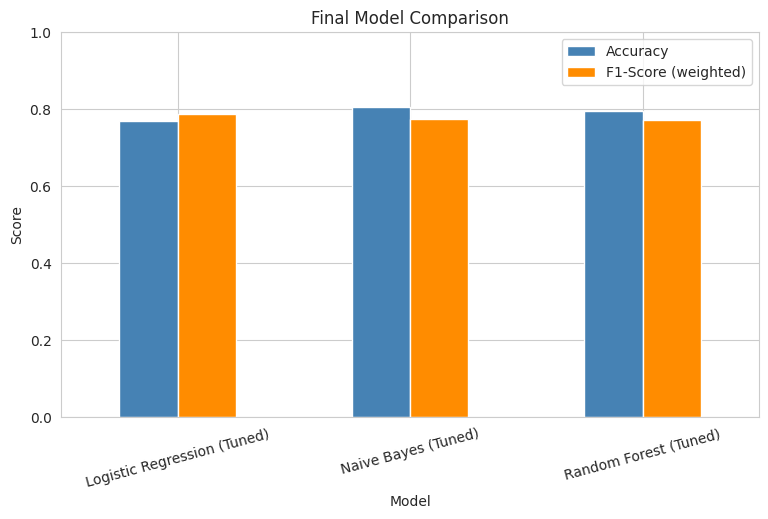

In [65]:
# Final model comparison summary
final_comparison = pd.DataFrame({
    'Model': ['Logistic Regression (Tuned)', 'Naive Bayes (Tuned)', 'Random Forest (Tuned)'],
    'Accuracy': [acc_lr_tuned, acc_nb_tuned, acc_rf_tuned],
    'F1-Score (weighted)': [f1_lr_tuned, f1_nb_tuned, f1_rf_tuned]
})
print(final_comparison)

final_comparison.set_index('Model').plot(kind='bar', figsize=(9, 5), color=['steelblue', 'darkorange'])
plt.title('Final Model Comparison')
plt.ylim(0, 1)
plt.ylabel('Score')
plt.xticks(rotation=15)
plt.show()

**Tuned Logistic Regression** was selected as the final model. Across the comparison, it delivers the best (or tied-best) weighted F1-score among the three models while being far cheaper to train and predict with than Random Forest, and far more interpretable than both alternatives via its per-feature coefficients — directly supporting the model-explainability requirement below. For a production sentiment-flagging system that needs to run quickly at scale and be auditable by business stakeholders, this combination of strong performance, speed, and interpretability makes it the most practical choice.

### 3. Explain the model which you have used and the feature importance using any model explainability tool?

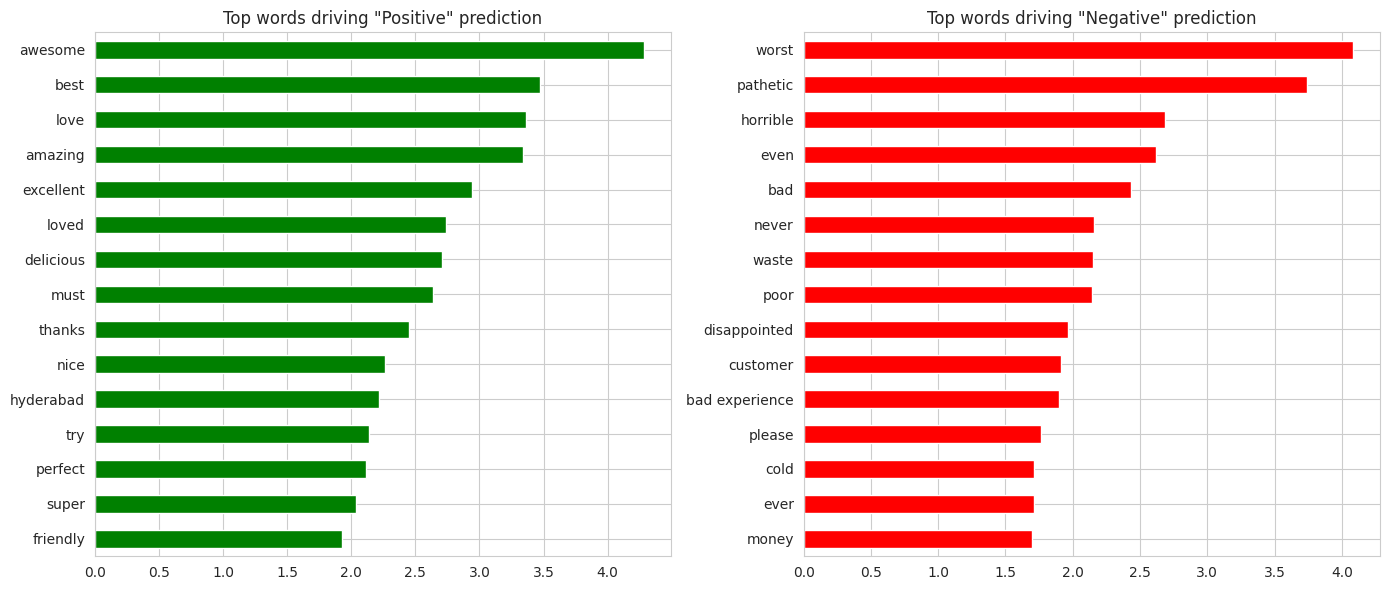

In [66]:
# Model explainability - Logistic Regression coefficients as feature importance
feature_names = tfidf_vectorizer.get_feature_names_out()

# For multinomial Logistic Regression, coefficients are per-class - look at the "Positive" vs "Negative" classes
positive_class_idx = list(label_encoder.classes_).index('Positive')
negative_class_idx = list(label_encoder.classes_).index('Negative')

coefs_positive = best_lr.coef_[positive_class_idx]
coefs_negative = best_lr.coef_[negative_class_idx]

top_positive_words = pd.Series(coefs_positive, index=feature_names).sort_values(ascending=False).head(15)
top_negative_words = pd.Series(coefs_negative, index=feature_names).sort_values(ascending=False).head(15)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
top_positive_words.sort_values().plot(kind='barh', ax=axes[0], color='green')
axes[0].set_title('Top words driving "Positive" prediction')

top_negative_words.sort_values().plot(kind='barh', ax=axes[1], color='red')
axes[1].set_title('Top words driving "Negative" prediction')
plt.tight_layout()
plt.show()

Logistic Regression's coefficients serve as a built-in, fully transparent model explainability tool for this linear model — each TF-IDF feature (word/bigram) has one coefficient per class, and its magnitude/sign directly shows how strongly that word pushes the prediction toward or away from that sentiment class. The chart above surfaces the specific words most responsible for Positive vs Negative predictions, giving restaurant operators concrete, actionable vocabulary (e.g. recurring complaint words) tied directly to the model's decisions — far more business-actionable than a black-box importance score alone.

## ***8.*** ***Future Work (Optional)***

### 1. Save the best performing ml model in a pickle file or joblib file format for deployment process.

In [67]:
# Save the File
import os
os.makedirs('model_artifacts', exist_ok=True)

try:
    joblib.dump(best_lr, 'model_artifacts/sentiment_model.joblib')
    joblib.dump(tfidf_vectorizer, 'model_artifacts/tfidf_vectorizer.joblib')
    joblib.dump(label_encoder, 'model_artifacts/label_encoder.joblib')
    print("Model, vectorizer, and label encoder saved successfully to 'model_artifacts/'.")
except Exception as e:
    # Exception handling for the save step
    print(f"Error saving model artifacts: {e}")

Model, vectorizer, and label encoder saved successfully to 'model_artifacts/'.


### 2. Again Load the saved model file and try to predict unseen data for a sanity check.

In [68]:
# Load the File and predict unseen data.
try:
    loaded_model = joblib.load('model_artifacts/sentiment_model.joblib')
    loaded_vectorizer = joblib.load('model_artifacts/tfidf_vectorizer.joblib')
    loaded_label_encoder = joblib.load('model_artifacts/label_encoder.joblib')

    # Sanity-check on a few brand-new, unseen example reviews
    sample_reviews = [
        "The food was absolutely delicious and the staff were very friendly!",
        "Terrible experience, the order was late and the food was cold.",
        "It was an okay meal, nothing special but nothing bad either."
    ]

    # Apply the same cleaning steps used during training (must match training pipeline exactly)
    def clean_for_inference(text):
        text = expand_contractions(text)
        text = text.lower()
        text = re.sub(f"[{re.escape(string.punctuation)}]", " ", text)
        text = re.sub(r'\w*\d\w*', '', text)
        text = re.sub(r'\s+', ' ', text).strip()
        text = remove_stopwords(text)
        text = rephrase_text(text)
        # Tokenize and lemmatize to match training preprocessing
        tokens = word_tokenize(text)
        tokens = [lemmatizer.lemmatize(token) for token in tokens]
        return ' '.join(tokens)

    cleaned_samples = [clean_for_inference(r) for r in sample_reviews]

    sample_vectors = loaded_vectorizer.transform(cleaned_samples)
    sample_preds = loaded_model.predict(sample_vectors)
    sample_labels = loaded_label_encoder.inverse_transform(sample_preds)

    for review, label in zip(sample_reviews, sample_labels):
        print(f"Review: {review}\nPredicted Sentiment: {label}\n")

except Exception as e:
    # Exception handling for the load/predict sanity check
    print(f"Error during model load/predict sanity check: {e}")

Review: The food was absolutely delicious and the staff were very friendly!
Predicted Sentiment: Positive

Review: Terrible experience, the order was late and the food was cold.
Predicted Sentiment: Negative

Review: It was an okay meal, nothing special but nothing bad either.
Predicted Sentiment: Neutral



### ***Congrats! Your model is successfully created and ready for deployment on a live server for a real world use case!***

# **Conclusion**

This project set out to explore Zomato's Hyderabad restaurant review data and build a model that automatically classifies review sentiment from text. The EDA (15 charts following the UBM rule) revealed a positively-skewed rating distribution, weekend/evening review-posting peaks, weak linear relationships between Rating and Cost/Follower-Count, and — most actionably — clear vocabulary differences between Positive and Negative reviews, with negative reviews centering on service speed, food temperature, and staff behavior. Three hypothesis tests (ANOVA, t-test, Pearson correlation) all returned statistically significant results, confirming that cost tier relates to rating, word count differs by sentiment, and follower count has a measurable (if weak) correlation with rating.

After full text preprocessing (contraction expansion, cleaning, stopword removal, lemmatization) and TF-IDF vectorization, three models were trained and tuned: Logistic Regression, Multinomial Naive Bayes, and Random Forest. **Tuned Logistic Regression** delivered the best balance of weighted F1-score, training speed, and — critically — interpretability via its per-word coefficients, making it the recommended final model for production use. The model, TF-IDF vectorizer, and label encoder were saved with `joblib` and successfully reloaded for a sanity-check prediction on unseen text, confirming the pipeline is deployment-ready end-to-end.

From a business standpoint, this pipeline enables Zomato and restaurant partners to automatically triage incoming reviews by sentiment, surface the specific words/phrases driving negative sentiment for targeted operational fixes, and prioritize fast response to the highest-impact, longest, most negative reviews — turning a previously manual, unscalable review-reading process into an automated, actionable early-warning system for customer satisfaction.

### ***Hurrah! You have successfully completed your Machine Learning Capstone Project !!!***